In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys, importlib, time
from tqdm import tqdm
tqdm.pandas()
sys.path.append(os.path.abspath(".."))

# my utils
from utils import preprocess_listings

# importlib.reload(modeling)
# from utils.modeling import add_booking_rate_l90d, add_booking_rate_l30d
# df=pd.read_csv("../data_processed/listings_paris2312_scores.csv")
# df_nextQ=pd.read_csv("../data_raw\listings_paris2403.csv")

# df_reviews=add_booking_rate_l90d(df, df_nextQ)


In [7]:
path_listings_tactics="../data_processed\listings_paris2312_scores.csv"
df_raw=pd.read_csv(path_listings_tactics)
df=df_raw.copy()
print(len(df))
print(df.columns)
display(df.head())


74330
Index(['Unnamed: 0', 'id', 'listing_url', 'scrape_id', 'last_scraped',
       'source', 'name', 'description', 'neighborhood_overview', 'picture_url',
       ...
       'responsive', 'fan of Airbnb', 'Airbnb community', 'love Airbnb',
       'travel with Airbnb', 'ouverture', 'authenticité', 'sociabilité',
       'auto_promotion', 'exemplarité'],
      dtype='object', length=104)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18456\352956351.py:2: DtypeWarning: Columns (7,23,42,46,47,62) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw=pd.read_csv(path_listings_tactics)


,Unnamed: 0,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,0,3109.0,https://www.airbnb.com/rooms/3109,2.023121e+13,2023-12-12,city scrape,Rental unit in Paris · ★5.0 · 1 bedroom · 1 be...,NaN,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/baeae9e2-cd53...,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,1,5396.0,https://www.airbnb.com/rooms/5396,2.023121e+13,2023-12-14,city scrape,Rental unit in Paris · ★4.59 · Studio · 1 bed ...,NaN,"You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,...,0.973056,0.285508,0.749040,0.137775,0.312311,0.565581,-0.008205,0.957697,1.416490,0.373926
2,2,81106.0,https://www.airbnb.com/rooms/81106,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.84 · 1 bedroom · 1 b...,NaN,The neighborhood will show you an other side o...,https://a0.muscache.com/pictures/miso/Hosting-...,...,0.639749,0.095681,0.093284,0.021362,0.258570,-0.404478,1.019766,-0.491341,0.606779,-0.441423
3,3,7397.0,https://www.airbnb.com/rooms/7397,2.023121e+13,2023-12-13,city scrape,Rental unit in Paris · ★4.73 · 2 bedrooms · 2 ...,NaN,NaN,https://a0.muscache.com/pictures/67928287/330b...,...,0.380097,0.000321,0.000877,0.000308,0.001214,-1.157850,-0.733577,-1.889289,-1.456089,-0.778443
4,4,7964.0,https://www.airbnb.com/rooms/7964,2.023121e+13,2023-12-12,city scrape,Rental unit in Paris · ★4.80 · 1 bedroom · 1 b...,NaN,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,...,0.535471,0.294100,0.898153,0.050386,0.692560,-0.620812,-0.982499,1.353823,1.013025,0.526214


# preprocess

In [30]:
# df['has_rating'] = df['review_scores_rating'].notna().astype(int)
# df['review_scores_rating'] = pd.to_numeric(df['review_scores_rating'], errors='coerce')#有文本？？先转数字再填？
# # 填0太极端，会破坏模型，在筛选后has_rating ==0在20%以下，可以选择平均值
# median_rating = df['review_scores_rating'].median()
# mean_rating = df['review_scores_rating'].mean()

# print(f"[INFO] missing review scores are filled by mean :{mean_rating}\n")
# df['review_scores_rating'] = df['review_scores_rating'].fillna(median_rating)

# print(df.review_scores_rating.value_counts(dropna=False))
# print(df.has_rating.value_counts(dropna=False))


## host variables

In [8]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import preprocess_host_variables, print_nan_ratio

df_processed=preprocess_host_variables(df) 
# 1.5MINS



******************************HOST VARS******************************
PROCESS PIPELINE :
- host_has_profile_pic : fillna('f') if not f/t
- host_identity_verified: fillna('f') if not f/t 
- host_is_sueprhost: check ONLY 't'/'f'; fillna('f')
- review_scores_rating: 24.0% NaN; fillna(mean), to numeric; ADD 'has_rating' 
- host_since: ADD 'years_since_host' :float, 0.5-1 year=>1， 0-0.5 year => 0 
- has_host_about: 'lang:en/fr/other_langs','len:int',
- host_response_time:41.0% NaN, fillna('no_response_time') 
- host_response_rate:41.0% NaN, ADD 'has_response_rate' :1/0， fillna(0)
- calculated_host_listings_count : ADD 'professional_host:1/0', count>1

[INFO] missing review scores are filled by mean :4.689369847503803

==========================HOST VARS================================
16 IMPO VARS:['host_picture_url', 'host_identity_verified', 'number_of_reviews', 'host_is_superhost', 'review_scores_rating', 'has_rating', 'host_since', 'years_since_host', 'host_about', 'lang', 'len', 'hos

## proxies and objectif vars

In [10]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import preprocess_obj_vars

df_nextQ=pd.read_csv("../data_raw\listings_paris2403.csv")


df_filtered=preprocess_obj_vars(df=df_processed, df_nextQ=df_nextQ, 
        proxy_vars=['price',"availability_30","availability_90"], 
        get_booking_rate_l30d=True, filtrate_by_booking_rate_l30d=True,#无输入时默认不按照booking筛选 
        get_booking_rate_l90d=True, filtrate_by_booking_rate_l90d=False,
        obj_vars=["room_type", 'property_type',"minimum_nights","instant_bookable"], 
        threshold_km=None, 
        output_folder="../data_processed", filename="listings_paris2312_scores_filtered.csv")

# df_filtered=preprocess_obj_vars(df=df_processed, proxy_vars=['price',"availability_30","availability_90"], 
#                         get_boooking_rate_l30d=True, filtrate_by_booking_rate=True,
#                         obj_vars=["room_type", "property_type","minimum_nights","instant_bookable"], 
#                         threshold_km=None, 
#                         output_folder="../data", filename='listings_tactics_filtered.csv')



==========================PROXY + OBJ VARS============================
PROCESS PIPELINE :
1) process proxies : 
- price : delete '$', to_numeric

 2) if get_boooking_rate_l30d==True, calculation method:
- booking_rate_l30d = number_of_reviews_l30d / availability_30 
 note that many 'number_of_reviews_l30d' is 0!
 if availability_30 = 0, take NaN.
 if booking_rate_l30d > 1, take 1.

3) if 'add_booking_rate_l90d':
 ADD number_of_reviews_nextQ, booking_rate_l90d 
 if host no longer exists in df_nextQ or substraction get negative value, number_of_reviews_nextQ=> nan 
 booking_rate_l30d = number_of_reviews_nextQ (Q3)/ availability_90 (Q2)
 if filter False: no filter on booking_rate, ava, nb_reviews

4) obj vars :
 - instant_bookable : fillna('f')
- minimum_nights : to_numeric, fillna(0)
- property_type : clean col : entire, hotel, shared, private, others.

5) filter : dropna on vars ==> desc df_filtered 

desc statistique :room_type, property_type, minimum_nights, instant_bookable 

6) if

In [12]:
print(df_filtered.booking_rate_l90d.isna().value_counts())

booking_rate_l90d
False    29221
True      7792
Name: count, dtype: int64


## desc :

In [14]:
import pandas as pd

import os, sys, importlib
from utils import preprocess_listings
# from utils preprocess_listings import 

# path_df_filtered="../data\listings_tactics_filtered.csv"
path_df_filtered="../data_processed\listings_paris2312_scores_filtered.csv"
df_filtered=pd.read_csv(path_df_filtered)
df_filtered.columns

Index(['Unnamed: 0', 'id', 'listing_url', 'scrape_id', 'last_scraped',
       'source', 'name', 'description', 'neighborhood_overview', 'picture_url',
       ...
       'years_since_host', 'has_since', 'lang', 'len', 'has_response_rate',
       'professional_host', 'booking_rate_l30d',
       'number_of_reviews_till_nextQ', 'number_of_reviews_nextQ',
       'booking_rate_l90d'],
      dtype='object', length=115)

In [15]:
from utils import preprocess_listings
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest
#---------------------------------------------------------------------------
all_host_vars= ['host_picture_url', "host_has_profile_pic", 'host_identity_verified', 'number_of_reviews',
           'review_scores_rating', 'has_rating', 'host_since', 'years_since_host', 'host_about', 
           'lang', 'len', 'host_response_time', 'host_response_rate', 'has_response_rate',
           'calculated_host_listings_count', 'professional_host',  'host_is_superhost']

proxy_obj_vars=['price', "availability_30", "number_of_reviews_l30d","booking_rate_l30d",
        "room_type", "minimum_nights","instant_bookable"]

# tactics_vars_mean=['ouverture_mean',"authenticité_mean","sociabilité_mean", "auto_promotion_mean","exemplarité_mean"]
# tactics_vars_weighted=["ouverture_pondéré", "authenticité_pondéré","sociabilité_pondéré","auto_promotion_pondéré","exemplarité_pondéré"]
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
group_col='host_is_superhost'


cols_to_check=[
    # "host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating",'number_of_reviews',
    "years_since_host", "professional_host",#'calculated_host_listings_count',
    # "lang", "len",
    "price", "availability_30","room_type", "instant_bookable"
]   

table = group_mean_table_ttest(df_filtered, cols_to_check=cols_to_check+tactics_vars, 
                               group_col="host_is_superhost",
                               save=True,
                               output_folder="../output_mod", 
                               filename_noext=None)
display(table)

[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :f vs t
[INFO] ttest on 37013 lines.

[WARNING]1 missing cols in df_input :
 number_of_reviews

[CHECK] ttest take ONLY numeric cols! 

[WARNING] no numeric cols:
 room_type; instant_bookable

✅ [SAVE] table host csv saved to ../output_mod\table_groupby_host_is_superhost.csv!

☑️[SAVE] Table saved as LaTeX to ../output_mod\latex\table_groupby_host_is_superhost.tex!



d:\Edu\selfpresentation-NLI-airbnb\utils\io.py:24: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna('-')
d:\Edu\selfpresentation-NLI-airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


host_is_superhost,Superhôte,Autres,ttest_p,significance
proportion,0.208927,0.791073,NaN,NaN
review_scores_rating,4.856127,4.675444,0.0,***
years_since_host,7.976206,6.720082,0.0,***
professional_host,0.414458,0.42541,0.082329,
price,228.37424,234.167589,0.408304,
availability_30,12.877667,16.373497,0.0,***
ouverture,0.056981,-0.089193,0.0,***
authenticité,0.098879,-0.170585,0.0,***
sociabilité,0.136152,-0.087733,0.0,***
auto_promotion,-0.012023,0.136159,0.0,***


[INFO] groups of host_is_superhost:['f' 't']


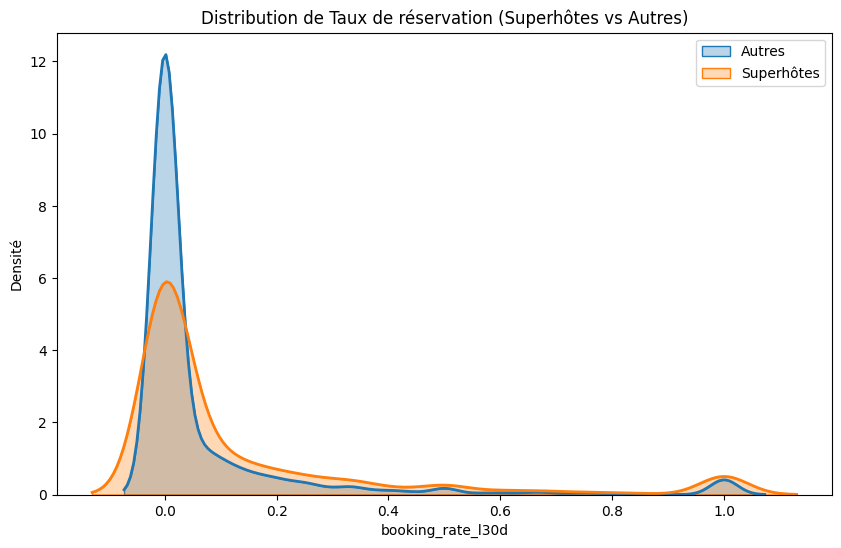

✅ [SAVE] plot distribution saved to ../output_mod\host_performance_on_booking_rate_l30d.jpg!


In [16]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import plot_distribution

plot_distribution(df=df_filtered, group_col="host_is_superhost", 
                  y_var='booking_rate_l30d', 
                  save=True,
                  output_folder="../output_mod")

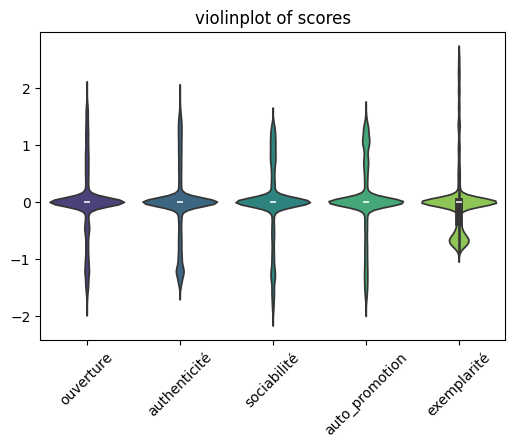

In [18]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import plot_violon

plot_violon(df_input=df_filtered, vars=tactics_vars, to_fillna0=True, output_folder="../output_mod", filename="violon_tactics_weighted.jpg")


## modeling

In [ ]:
import os, sys, importlib
import pandas as pd
sys.path.append (os.path.abspath(".."))
from utils import modeling
importlib.reload(modeling)
from utils.modeling import write_formula, check_vif, build_model

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)



path_df_filtered="../data_processed\listings_paris2312_scores_filtered.csv"
df_filtered=pd.read_csv(path_df_filtered)

#************************************************************************************************#
y_var="booking_rate_l30d"

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", "has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', 'calculated_host_listings_count',
    "lang", "len",
    "price", "availability_30", "room_type", "instant_bookable"
]  
#calculated_host_listings_count
# "property_type"

# tactics_vars_weighted=["ouverture_weighted", "authenticité_weighted","sociabilité_weighted","auto_promotion_weighted","exemplarité_weighted"]    
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
group_col="host_is_superhost"



# output_folder='mod_results'
# output_folder='mod_results+rating+listing_count'
# output_folder='mod_results+rating+listing_count+nb_reviews'

output_folder='../output_mod'


=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ../output_mod/booking30-superhost!


 ============================================basic model============================================= 

[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  lang   len    price  availability_30  room_type  instant_bookable  booking_rate_l30d
False                   False                 False                 False             False              False              False  False  False  False            False      False             False                37013
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) +

,Basique,Tactiques,x Superhôte
C(host_is_superhost)[T.t],0.0396***\n(0.0026),0.0388***\n(0.0026),0.0395***\n(0.0026)
ouverture,,-0.0024\n(0.0020),0.0004\n(0.0023)
C(host_is_superhost)[T.t]:ouverture,,,-0.0105**\n(0.0041)
authenticité,,0.0042**\n(0.0022),0.0070***\n(0.0025)
C(host_is_superhost)[T.t]:authenticité,,,-0.0100**\n(0.0047)
sociabilité,,0.0077***\n(0.0019),0.0080***\n(0.0022)
C(host_is_superhost)[T.t]:sociabilité,,,-0.0012\n(0.0044)
auto_promotion,,-0.0006\n(0.0022),0.0042*\n(0.0026)
C(host_is_superhost)[T.t]:auto_promotion,,,-0.0173***\n(0.0048)
exemplarité,,-0.0060***\n(0.0019),-0.0095***\n(0.0021)


,Basique,Tactiques,x Superhôte
C(host_identity_verified)[T.t],0.0092*\n(0.0048),0.0093*\n(0.0048),0.0091*\n(0.0048)
C(host_has_profile_pic)[T.t],-0.0001\n(0.0059),0.0003\n(0.0059),0.0000\n(0.0059)
C(lang)[T.fr],0.0103***\n(0.0031),0.0092***\n(0.0034),0.0092***\n(0.0034)
C(lang)[T.no_text],0.0081***\n(0.0030),0.0090***\n(0.0032),0.0090***\n(0.0032)
C(lang)[T.other_langs],0.0155\n(0.0101),0.0173*\n(0.0102),0.0177*\n(0.0102)
C(room_type)[T.Hotel room],-0.0408***\n(0.0086),-0.0431***\n(0.0087),-0.0442***\n(0.0087)
C(room_type)[T.Private room],0.0264***\n(0.0033),0.0250***\n(0.0034),0.0252***\n(0.0034)
C(room_type)[T.Shared room],0.0182\n(0.0119),0.0163\n(0.0119),0.0162\n(0.0119)
C(instant_bookable)[T.t],0.0155***\n(0.0024),0.0160***\n(0.0025),0.0154***\n(0.0025)
review_scores_rating,-0.0006\n(0.0027),-0.0010\n(0.0027),-0.0012\n(0.0027)


☑️[SAVE] Table saved as LaTeX to ../output_mod/booking30-superhost\latex\table_mods_keyvars.tex!

☑️[SAVE] Table saved as LaTeX to ../output_mod/booking30-superhost\latex\table_mods_ctrlvars.tex!

===========================================tactics plots============================================
[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


...

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[SAVE] plots saved to ../output_mod/booking30-superhost\booking_rate_l30d_tactics_plots.jpg!


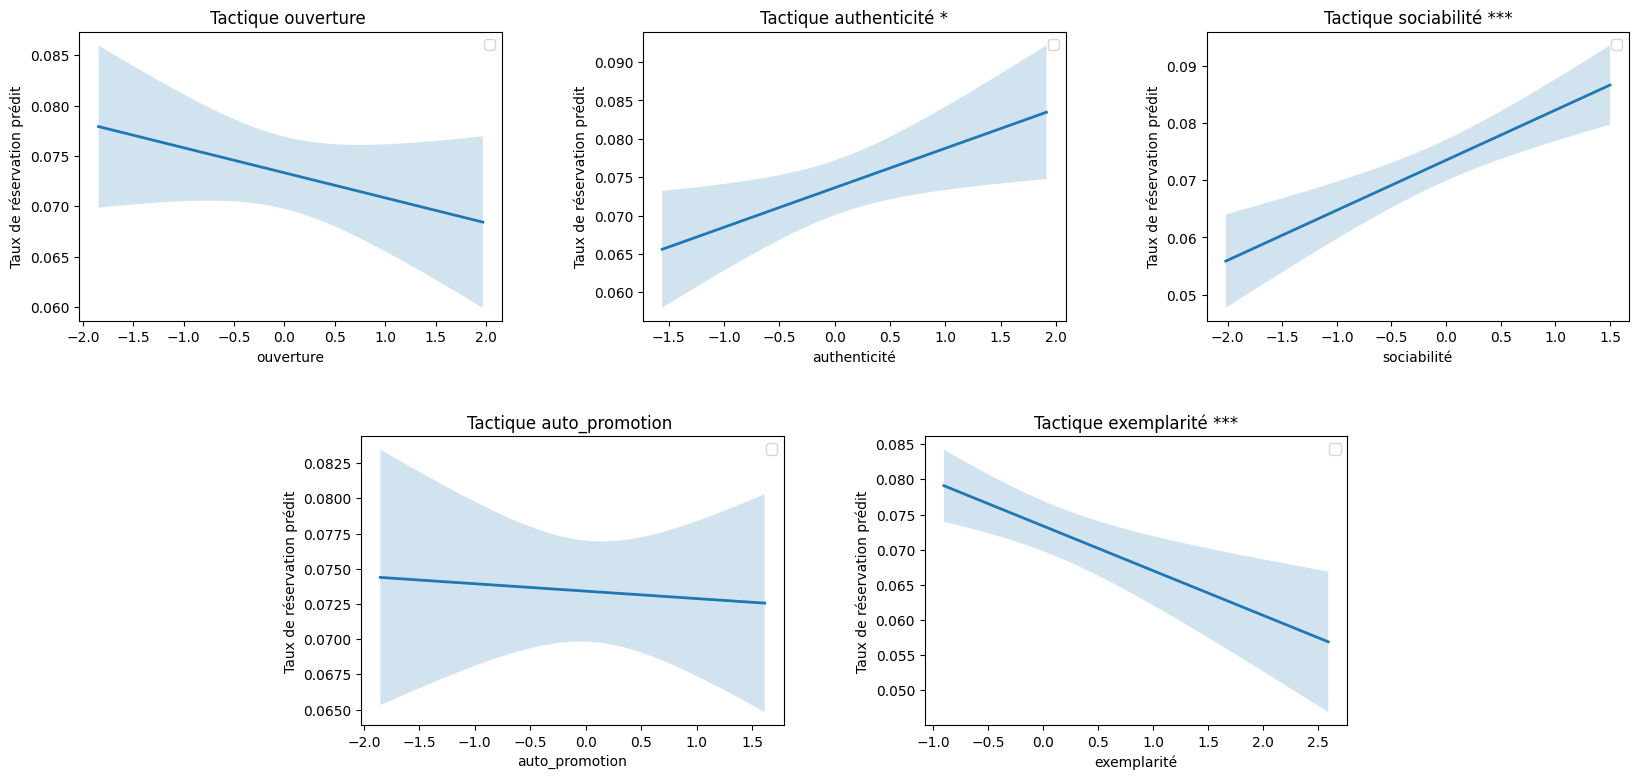

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:openness
coef : [-0.01002201]; pval :0.005 

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:authenticity
coef : [-0.00307849]; pval :0.451 

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lan

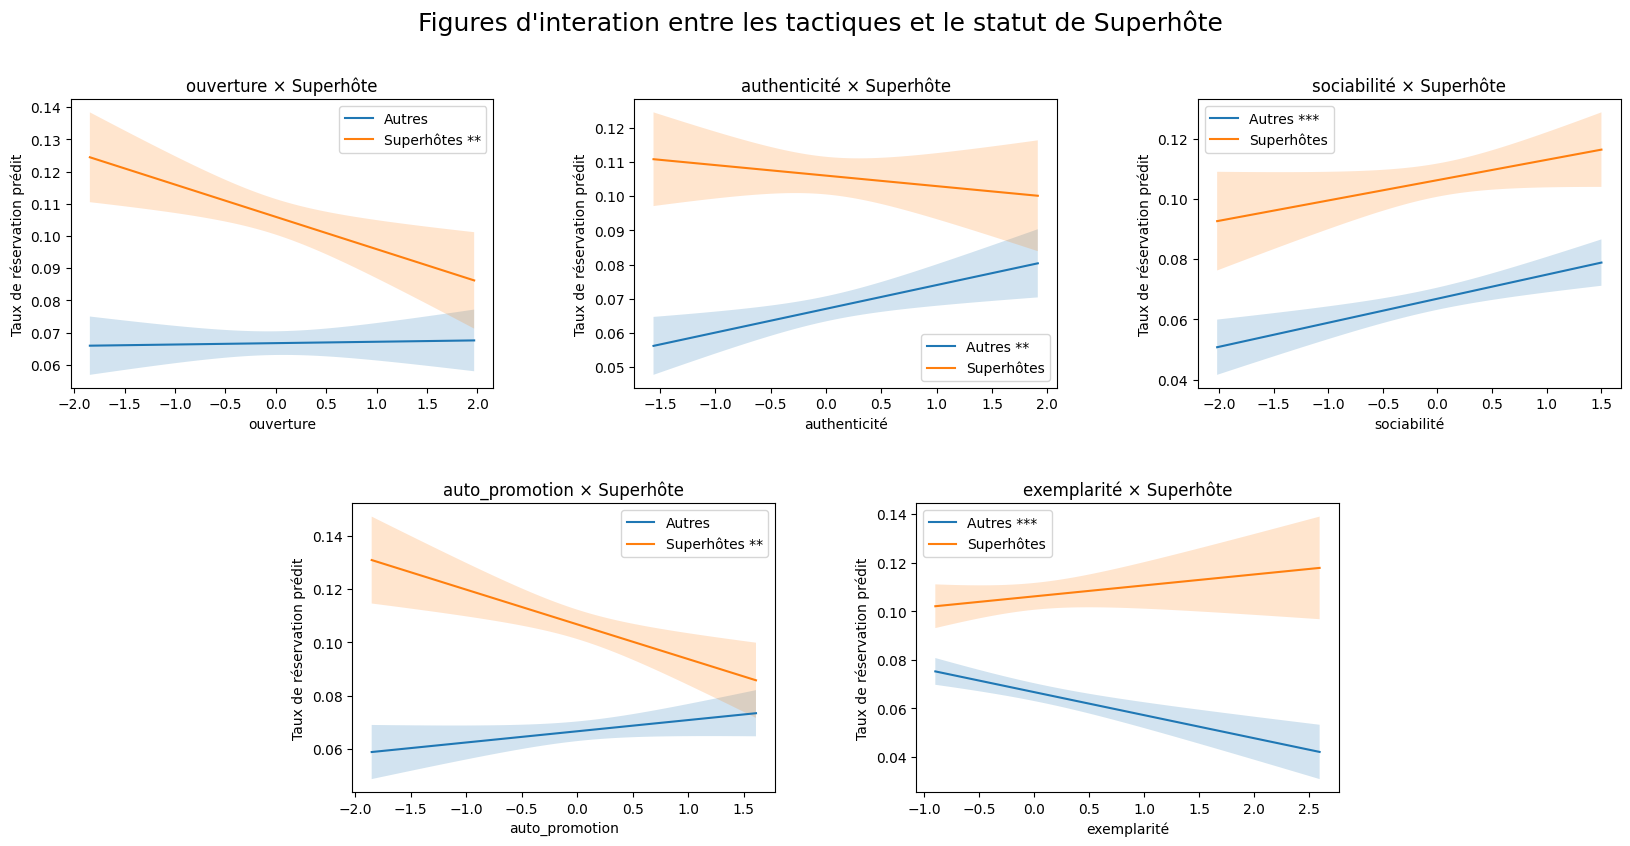

In [ ]:
## baseline :
y_var="booking_rate_l30d"

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', #'calculated_host_listings_count',
    "lang", "len",
    "price", "availability_30", "room_type", "instant_bookable"
]  
#加不加has_rating, count差别不大！
# calculated_host_listings_count
# "property_type"
 
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
group_col="host_is_superhost"

importlib.reload(modeling)
from utils.modeling import modeling_main

modeling_main(df_input=df_filtered, 
            x_vars=x_vars, 
            y_var='booking_rate_l30d', 
            key_vars=tactics_vars, 
            group_col="host_is_superhost",
            output_folder='../output_mod/booking30-superhost',
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=True,
            save_plots=True,
            ndigits=4
            )


# modeling_main(df_input=df_filtered, 
#             x_vars=x_vars, 
#             y_var=y_var, 
#             key_vars=tactics_vars, 
#             group_col=group_col,
#             OUTPUT_FOLDER=output_folder,
#             run_vif=False, 
#             save_models_table=True,
#             save_plots=True, 
#             ROUND=4
#             )

In [ ]:
print(df_filtered[["availability_90"]].value_counts(dropna=False))
print("ava90==0:",len(df_filtered[df_filtered["availability_90"]==0]))
print(df_filtered[["number_of_reviews_nextQ"]].value_counts(dropna=False))
df_filtered_90=

availability_90
90.0               2344
89.0               1964
88.0               1339
87.0               1026
83.0                903
                   ... 
34.0                190
42.0                181
38.0                179
36.0                177
37.0                175
Name: count, Length: 90, dtype: int64
ava90==0: 0
number_of_reviews_nextQ
0.0                        13231
NaN                         7792
1.0                         5193
2.0                         2869
3.0                         1761
4.0                         1214
5.0                          954
6.0                          725
7.0                          572
8.0                          471
9.0                          400
10.0                         314
11.0                         265
12.0                         217
13.0                         203
14.0                         163
15.0                         129
16.0                         115
17.0                          79
18.0               

In [32]:
df_filtered.instant_bookable.isna().value_counts(dropna=False)

instant_bookable
False    37013
Name: count, dtype: int64

=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ../output_mod/reviewsQ-superhost!


 ============================================basic model============================================= 

[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  lang   len    price  availability_90  room_type  instant_bookable  number_of_reviews_nextQ
False                   False                 False                 False             False              False              False  False  False  False            False      False             False                      29221
                                                                                                                                  

,Basique,Tactiques,x Superhôte
C(host_is_superhost)[T.t],1.3253***\n(0.0614),1.2909***\n(0.0614),1.3062***\n(0.0617)
ouverture,,-0.1053**\n(0.0488),-0.0552\n(0.0569)
C(host_is_superhost)[T.t]:ouverture,,,-0.1744*\n(0.0974)
authenticité,,0.2113***\n(0.0525),0.2858***\n(0.0613)
C(host_is_superhost)[T.t]:authenticité,,,-0.2485**\n(0.1116)
sociabilité,,0.2908***\n(0.0472),0.2817***\n(0.0550)
C(host_is_superhost)[T.t]:sociabilité,,,0.0325\n(0.1059)
auto_promotion,,-0.1077*\n(0.0559),-0.0050\n(0.0644)
C(host_is_superhost)[T.t]:auto_promotion,,,-0.3365***\n(0.1134)
exemplarité,,-0.0176\n(0.0476),-0.1119**\n(0.0550)


,Basique,Tactiques,x Superhôte
C(host_identity_verified)[T.t],0.7772***\n(0.1213),0.7622***\n(0.1212),0.7580***\n(0.1212)
C(host_has_profile_pic)[T.t],0.1690\n(0.1646),0.1915\n(0.1644),0.1842\n(0.1644)
C(lang)[T.fr],0.3039***\n(0.0754),0.1800**\n(0.0838),0.1780**\n(0.0838)
C(lang)[T.no_text],0.0449\n(0.0782),0.0221\n(0.0821),0.0163\n(0.0821)
C(lang)[T.other_langs],0.3215\n(0.2569),0.3620\n(0.2576),0.3681\n(0.2576)
C(room_type)[T.Hotel room],-1.7383***\n(0.1992),-1.7970***\n(0.1994),-1.8131***\n(0.1995)
C(room_type)[T.Private room],0.4620***\n(0.0844),0.4195***\n(0.0846),0.4236***\n(0.0846)
C(room_type)[T.Shared room],0.7850**\n(0.3105),0.6964**\n(0.3103),0.6948**\n(0.3102)
C(instant_bookable)[T.t],0.8496***\n(0.0631),0.9019***\n(0.0635),0.8908***\n(0.0636)
review_scores_rating,0.1205\n(0.0769),0.1027\n(0.0768),0.0970\n(0.0769)


☑️[SAVE] Table saved as LaTeX to ../output_mod/reviewsQ-superhost\latex\table_mods_keyvars.tex!

☑️[SAVE] Table saved as LaTeX to ../output_mod/reviewsQ-superhost\latex\table_mods_ctrlvars.tex!

===========================================tactics plots============================================
[INFO] formula :
 number_of_reviews_nextQ ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


...

[INFO] formula :
 number_of_reviews_nextQ ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 number_of_reviews_nextQ ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[SAVE] plots saved to ../output_mod/reviewsQ-superhost\number_of_reviews_nextQ_tactics_plots.jpg!


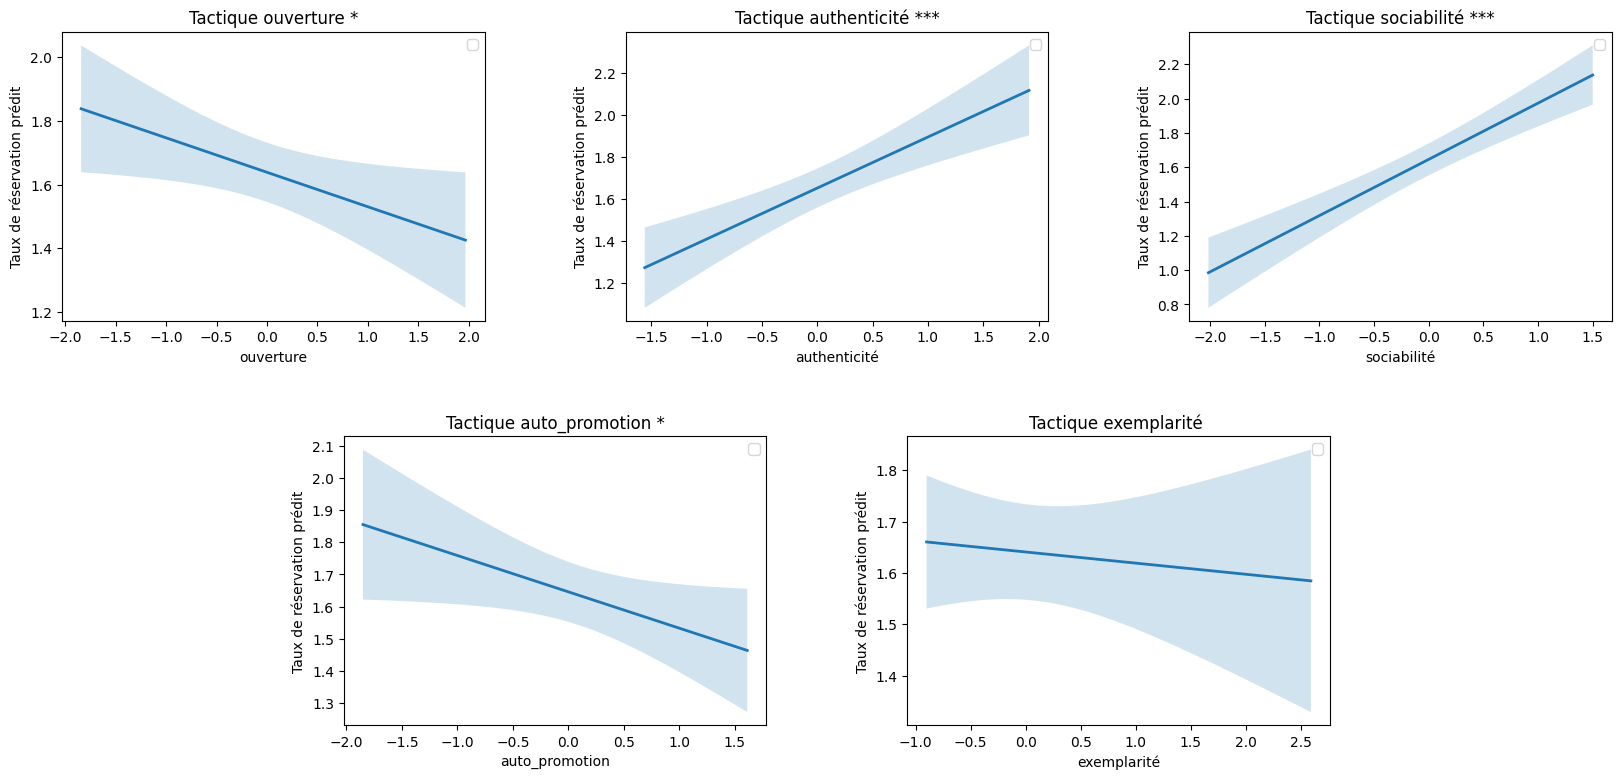

=========================================interaction plots==========================================
[INFO] formula :
 number_of_reviews_nextQ ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:openness
coef : [-0.22956257]; pval :0.006 

[INFO] formula :
 number_of_reviews_nextQ ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:authenticity
coef : [0.03725323]; pval :0.697 

[INFO] formula :
 number_of_reviews_nextQ ~ C(host_identity_verified) + C(host_has_pro

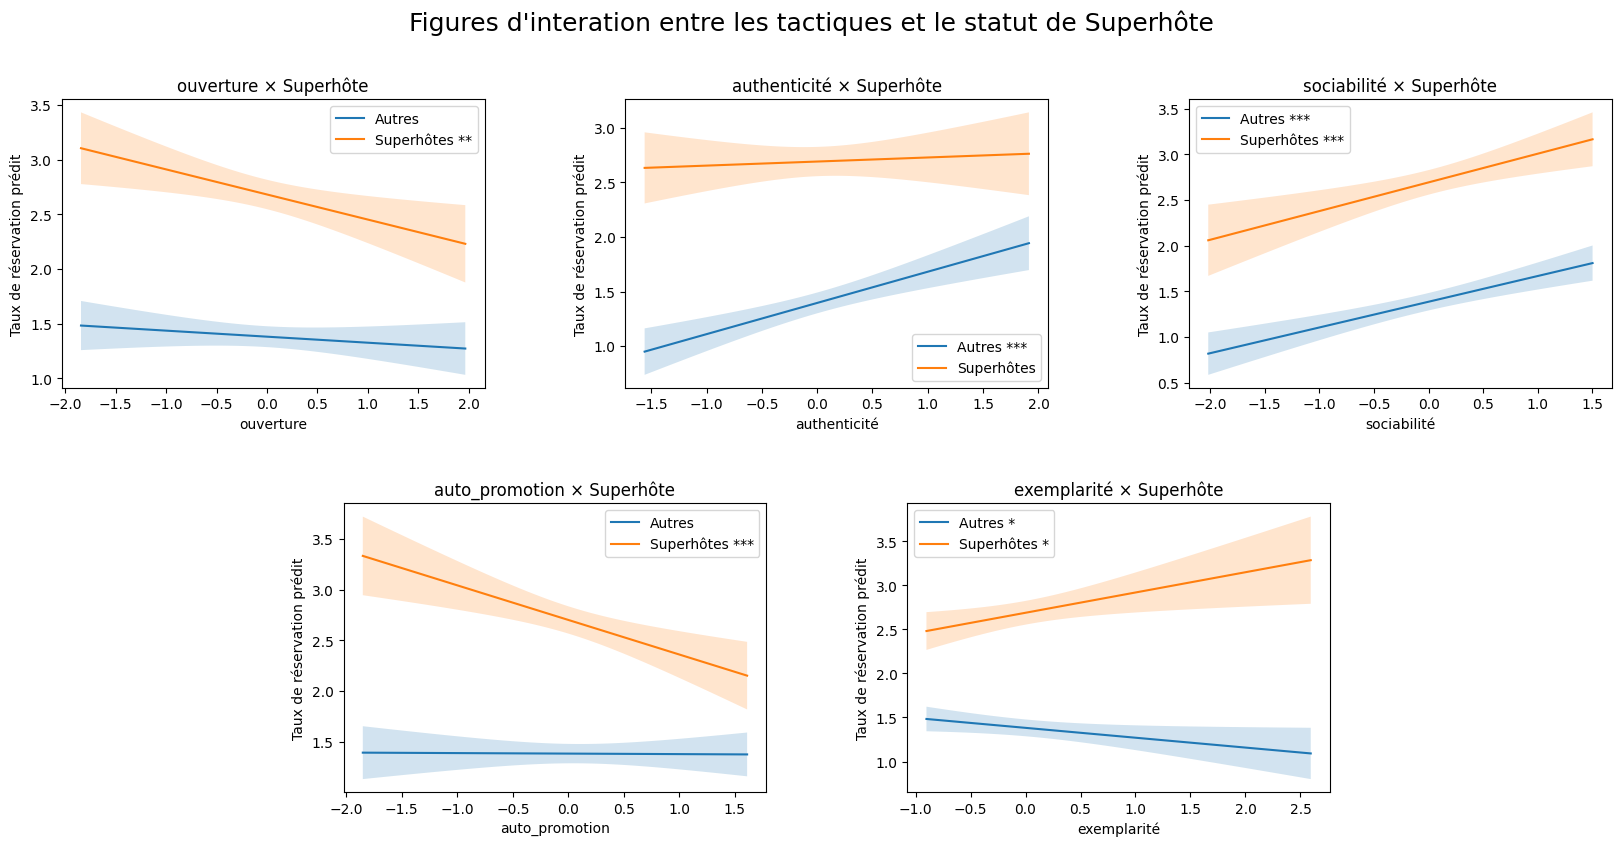

In [33]:
## reviews
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', #'calculated_host_listings_count',
    "lang", "len",
    "price", "availability_90", "room_type", "instant_bookable"
]  
#加不加has_rating, count差别不大！
# calculated_host_listings_count
# "property_type"
 
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]


importlib.reload(modeling)
from utils.modeling import modeling_main
modeling_main(df_input=df_filtered, 
            x_vars=x_vars, 
            y_var='number_of_reviews_nextQ', 
            key_vars=tactics_vars, 
            group_col="host_is_superhost",
            output_folder='../output_mod/reviewsQ-superhost',
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=True,
            save_plots=True,
            ndigits=4
            )


=============================================check data=============================================
[INFO] fillna in key cols!`

========================================check output folder=========================================
[INFO] results saved to ../output_mod/booking90-superhost!


 ============================================basic model============================================= 

[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  lang   len    price  availability_90  room_type  instant_bookable  booking_rate_l90d
False                   False                 False                 False             False              False              False  False  False  False            False      False             False                29221
                                                                                                                                             

,Basique,Tactiques,x Superhôte
C(host_is_superhost)[T.t],0.0373***\n(0.0026),0.0363***\n(0.0026),0.0365***\n(0.0026)
ouverture,,-0.0024\n(0.0020),-0.0023\n(0.0024)
C(host_is_superhost)[T.t]:ouverture,,,-0.0002\n(0.0041)
authenticité,,0.0046**\n(0.0022),0.0063**\n(0.0026)
C(host_is_superhost)[T.t]:authenticité,,,-0.0055\n(0.0047)
sociabilité,,0.0083***\n(0.0020),0.0087***\n(0.0023)
C(host_is_superhost)[T.t]:sociabilité,,,-0.0001\n(0.0044)
auto_promotion,,-0.0069***\n(0.0023),-0.0016\n(0.0027)
C(host_is_superhost)[T.t]:auto_promotion,,,-0.0187***\n(0.0047)
exemplarité,,0.0015\n(0.0020),0.0007\n(0.0023)


,Basique,Tactiques,x Superhôte
C(host_identity_verified)[T.t],0.0206***\n(0.0051),0.0201***\n(0.0051),0.0200***\n(0.0051)
C(host_has_profile_pic)[T.t],0.0070\n(0.0069),0.0078\n(0.0069),0.0076\n(0.0069)
C(lang)[T.fr],0.0056*\n(0.0032),0.0022\n(0.0035),0.0023\n(0.0035)
C(lang)[T.no_text],0.0015\n(0.0033),0.0015\n(0.0034),0.0015\n(0.0034)
C(lang)[T.other_langs],-0.0005\n(0.0107),0.0004\n(0.0108),0.0006\n(0.0108)
C(room_type)[T.Hotel room],-0.0267***\n(0.0083),-0.0286***\n(0.0083),-0.0288***\n(0.0084)
C(room_type)[T.Private room],0.0163***\n(0.0035),0.0150***\n(0.0035),0.0151***\n(0.0035)
C(room_type)[T.Shared room],0.0290**\n(0.0130),0.0262**\n(0.0130),0.0264**\n(0.0130)
C(instant_bookable)[T.t],0.0148***\n(0.0026),0.0167***\n(0.0027),0.0162***\n(0.0027)
review_scores_rating,0.0045\n(0.0032),0.0040\n(0.0032),0.0042\n(0.0032)


☑️[SAVE] Table saved as LaTeX to ../output_mod/booking90-superhost\latex\table_mods_keyvars.tex!

☑️[SAVE] Table saved as LaTeX to ../output_mod/booking90-superhost\latex\table_mods_ctrlvars.tex!

===========================================tactics plots============================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


...

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[SAVE] plots saved to ../output_mod/booking90-superhost\booking_rate_l90d_tactics_plots.jpg!


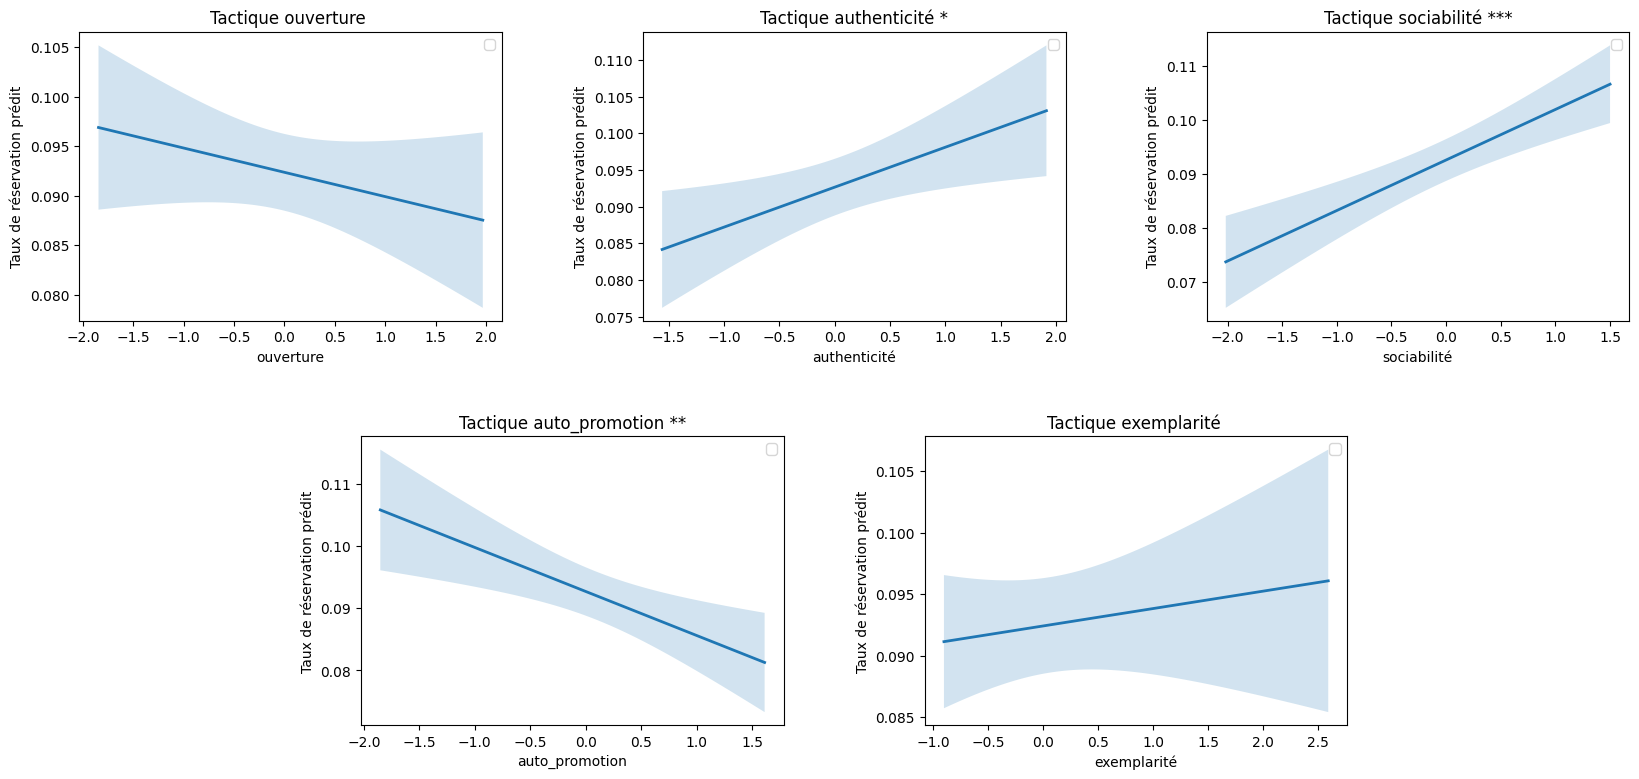

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:openness
coef : [-0.00252641]; pval :0.472 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_90+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:authenticity
coef : [0.00082455]; pval :0.837 

[INFO] formula :
 booking_rate_l90d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang

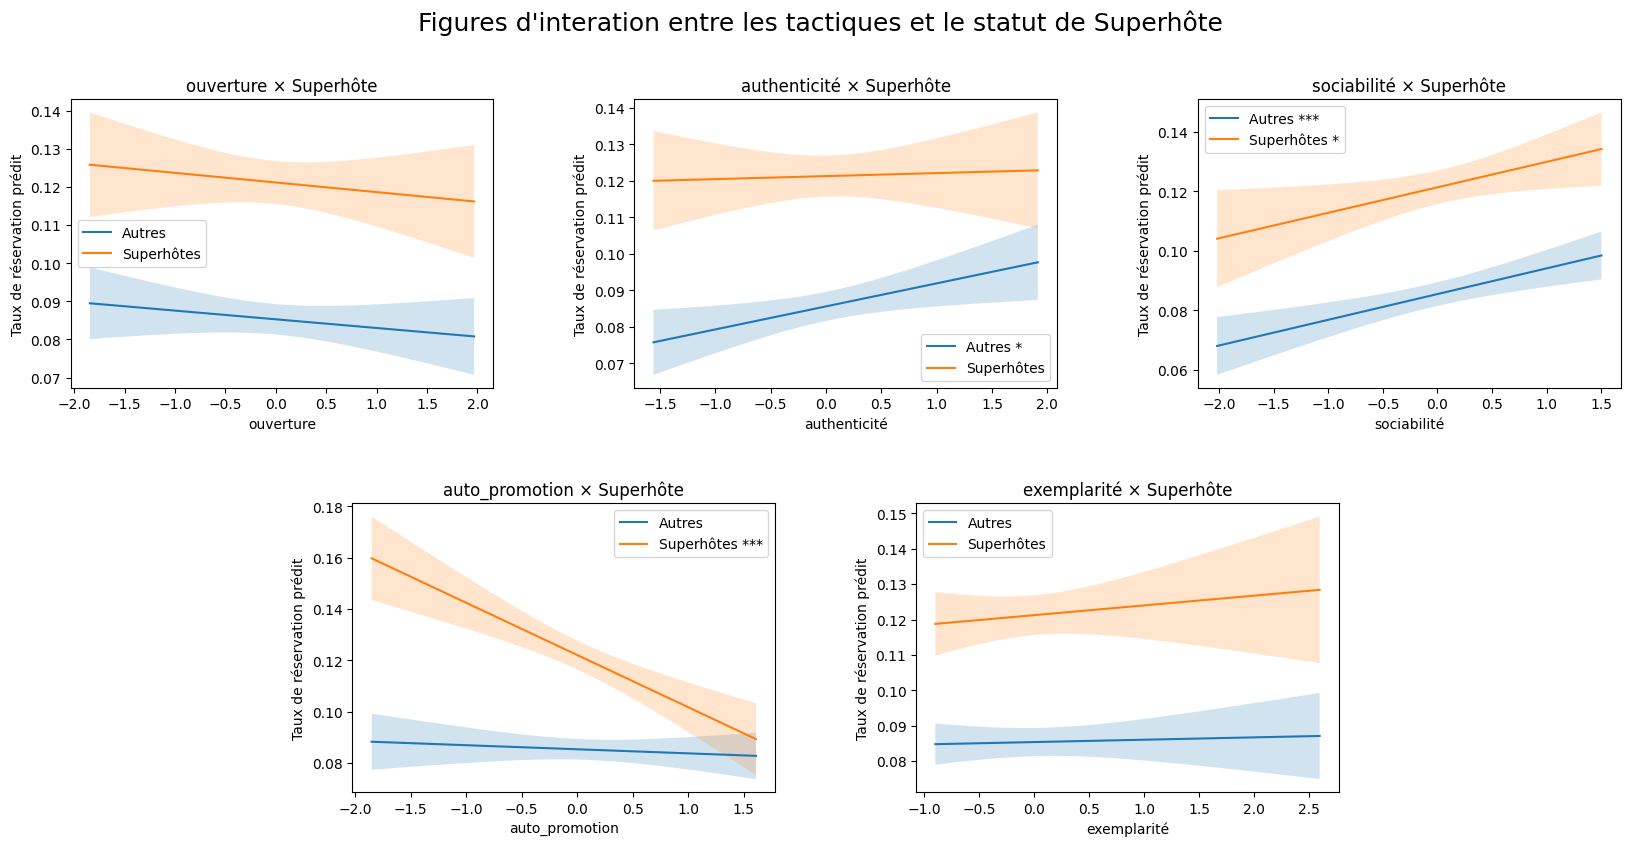

In [34]:
importlib.reload(modeling)
from utils.modeling import modeling_main

## reviews
x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', #'calculated_host_listings_count',
    "lang", "len",
    "price", "availability_90", "room_type", "instant_bookable"
]  
#加不加has_rating, count差别不大！
# calculated_host_listings_count
# "property_type"
 
tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]



modeling_main(df_input=df_filtered, 
            x_vars=x_vars, 
            y_var='booking_rate_l90d', 
            key_vars=tactics_vars, 
            group_col="host_is_superhost",
            output_folder='../output_mod/booking90-superhost',
            to_fillna0=True,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=True,
            save_plots=True,
            ndigits=4
            )


## other tries:

========================================check output folder=========================================
[INFO] results saved to mod_results+rating+listing_count!

============================================basic model=============================================
[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  has_rating  years_since_host  professional_host  host_is_superhost  calculated_host_listings_count  lang   len    price  availability_30  room_type  instant_bookable  booking_rate_l30d
False                   False                 False                 False       False             False              False              False                           False  False  False  False            False      False             False                37013
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) +

,Basique,Tactiques,x Superhôte
C(host_is_superhost)[T.t],0.0253***\n(0.0026),0.0250***\n(0.0026),0.0255***\n(0.0026)
ouverture,,-0.0016\n(0.0020),0.0013\n(0.0023)
C(host_is_superhost)[T.t]:ouverture,,,-0.0105***\n(0.0040)
authenticité,,0.0019\n(0.0021),0.0041\n(0.0025)
C(host_is_superhost)[T.t]:authenticité,,,-0.0081*\n(0.0047)
sociabilité,,0.0055***\n(0.0019),0.0055**\n(0.0022)
C(host_is_superhost)[T.t]:sociabilité,,,0.0002\n(0.0044)
auto_promotion,,-0.0004\n(0.0022),0.0045*\n(0.0025)
C(host_is_superhost)[T.t]:auto_promotion,,,-0.0177***\n(0.0047)
exemplarité,,-0.0052***\n(0.0019),-0.0084***\n(0.0021)


,Basique,Tactiques,x Superhôte
C(host_identity_verified)[T.t],0.0072\n(0.0048),0.0074\n(0.0048),0.0071\n(0.0048)
C(host_has_profile_pic)[T.t],-0.0089\n(0.0059),-0.0086\n(0.0059),-0.0089\n(0.0059)
C(lang)[T.fr],0.0078***\n(0.0030),0.0076**\n(0.0034),0.0077**\n(0.0034)
C(lang)[T.no_text],0.0091***\n(0.0030),0.0102***\n(0.0031),0.0102***\n(0.0031)
C(lang)[T.other_langs],0.0139\n(0.0100),0.0153\n(0.0101),0.0157\n(0.0100)
C(room_type)[T.Hotel room],-0.0511***\n(0.0086),-0.0524***\n(0.0086),-0.0533***\n(0.0086)
C(room_type)[T.Private room],0.0260***\n(0.0033),0.0251***\n(0.0033),0.0254***\n(0.0033)
C(room_type)[T.Shared room],0.0224*\n(0.0117),0.0212*\n(0.0118),0.0212*\n(0.0118)
C(instant_bookable)[T.t],0.0175***\n(0.0024),0.0175***\n(0.0024),0.0170***\n(0.0024)
review_scores_rating,0.0140***\n(0.0027),0.0136***\n(0.0027),0.0134***\n(0.0027)


☑️[SAVE] Table saved as LaTeX to mod_results+rating+listing_count\latex\table_mods_keyvars.tex!

☑️[SAVE] Table saved as LaTeX to mod_results+rating+listing_count\latex\table_mods_ctrlvars.tex!

===========================================tactics plots============================================
[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:552: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


...

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:552: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture + authenticité + sociabilité + auto_promotion + exemplarité



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:552: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


[SAVE] plots saved to mod_results+rating+listing_count\tactics_plots.jpg!


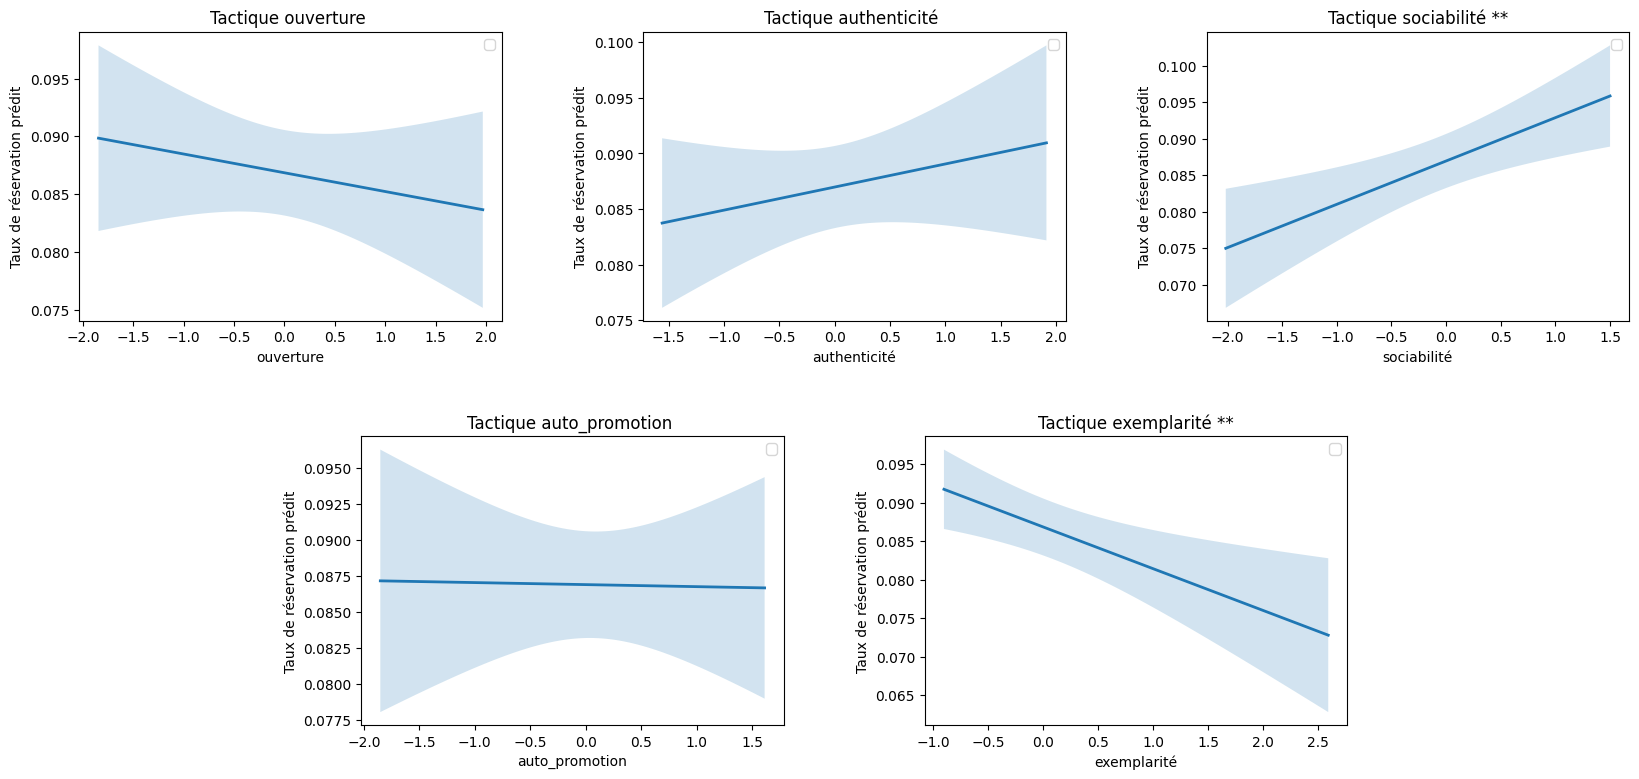

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:openness
coef : [-0.00919325]; pval :0.009 

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ C(host_is_superhost) * (ouverture + authenticité + sociabilité + auto_promotion + exemplarité)

C(host_is_superhost)[T.t]:authenticity
coef : [-0.00406944]; pval :0.314 

[INFO

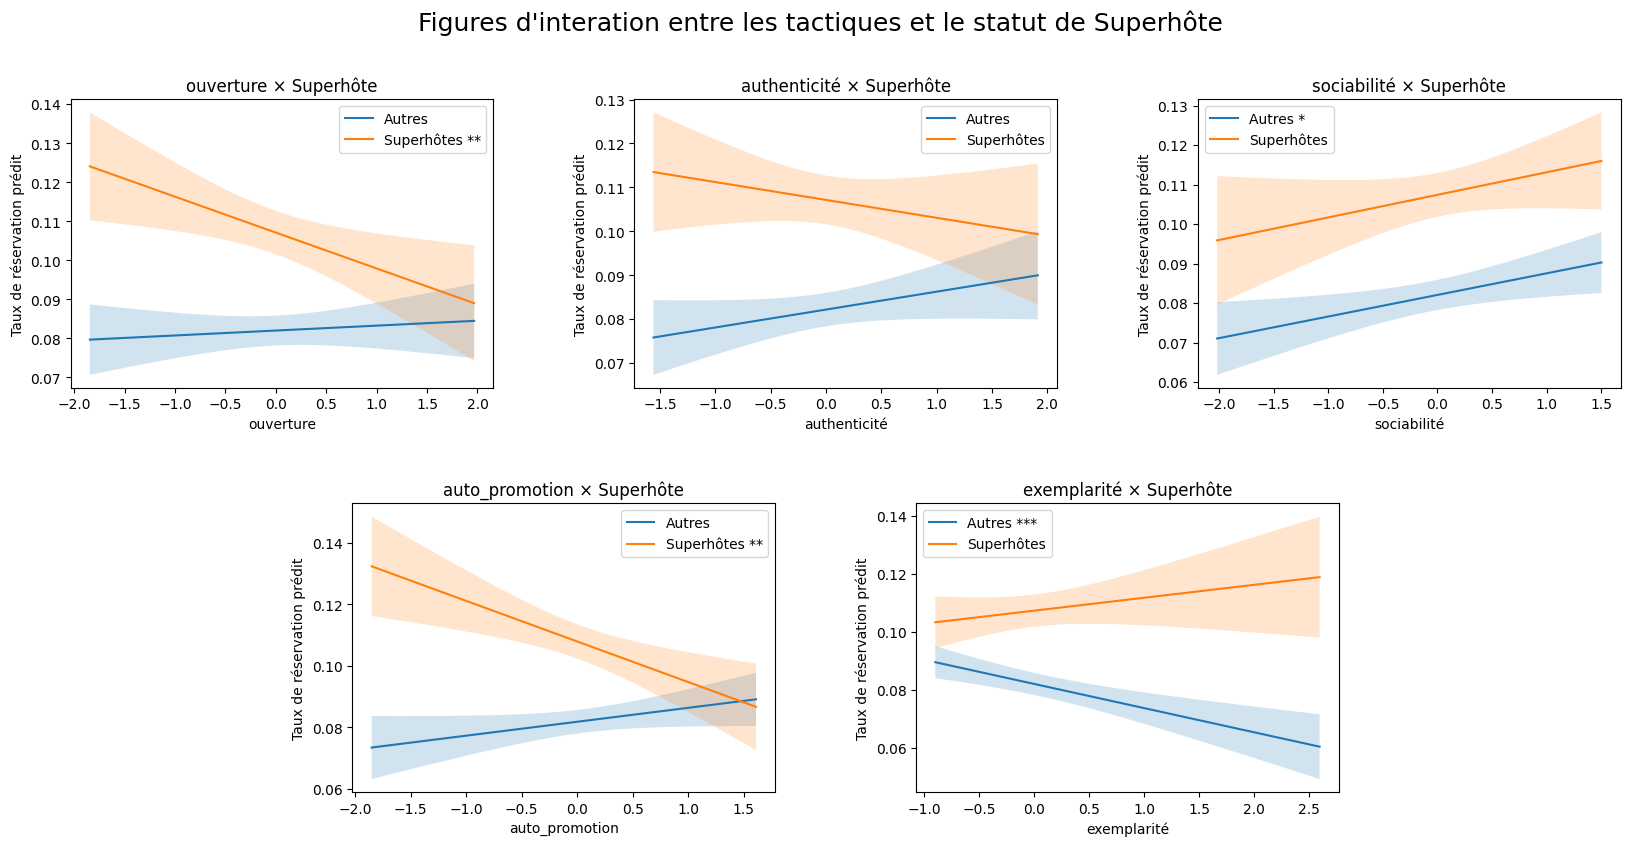

In [ ]:
# + rating + listings_counts

y_var="booking_rate_l30d"

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", "has_rating", #"number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', 'calculated_host_listings_count',
    "lang", "len",
    "price", "availability_30", "room_type", "instant_bookable"
]  
#加不加has_rating, count差别不大！
# calculated_host_listings_count
# "property_type"

tactics_vars=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
group_col="host_is_superhost"

output_folder='mod_results+rating+listing_count'


importlib.reload(modeling)
from utils.modeling import modeling_main
modeling_main(df_input=df_filtered, 
            x_vars=x_vars, 
            y_var=y_var, 
            key_vars=tactics_vars, 
            group_col=group_col,
            OUTPUT_FOLDER=output_folder,
            run_vif=False,
            # save_models_summary=False,  
            save_models_table=True,
            save_plots=True, 
            ROUND=4
            )

# pb de nb d'avis

In [56]:
y_var="number_of_reviews_l30d"

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', #'calculated_host_listings_count',
    "lang", "len",
    "price", "availability_30", "room_type", "instant_bookable"
]  
#加不加has_rating, count差别不大！
# calculated_host_listings_count
# "property_type"
 
tactics_vars_weighted=["ouverture_weighted", "authenticité_weighted","sociabilité_weighted","auto_promotion_weighted","exemplarité_weighted"]    
group_col="host_is_superhost"


output_folder='mod_results_Y_nb_reviews_l30d'

importlib.reload(modeling)
from utils.modeling import modeling_main
modeling_main(df_input=df_filtered, 
            x_vars=x_vars, 
            y_var=y_var, 
            key_vars=tactics_vars_weighted, 
            group_col=group_col,
            output_folder=output_folder,
            save_models_summary=False,  
            save_models_table=True,
            save_plots=True
            )

TypeError: modeling_main() got an unexpected keyword argument 'output_folder'

========================================check output folder=========================================
[INFO] results saved to mod_results_Y_nb_reviews!

================================================vif=================================================
============================================basic model=============================================
[CHECK] isna False in all 13 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  years_since_host  professional_host  host_is_superhost  lang   len    price  availability_30  room_type  instant_bookable  number_of_reviews
False                   False                 False                 False             False              False              False  False  False  False            False      False             False                37013
Name: count, dtype: int64

[INFO] formula :
 number_of_reviews ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookab

,Basique,Tactiques,x Superhôte
C(host_is_superhost)[T.t],29.3888***\n(0.7766),28.7882***\n(0.7762),28.6208***\n(0.7784)
ouverture_weighted,,-2.2440***\n(0.6052),-1.3985**\n(0.6938)
C(host_is_superhost)[T.t]:ouverture_weighted,,,-2.6523**\n(1.2371)
authenticité_weighted,,4.0470***\n(0.6526),3.8159***\n(0.7530)
C(host_is_superhost)[T.t]:authenticité_weighted,,,1.0890\n(1.4275)
sociabilité_weighted,,5.0792***\n(0.5820),3.6967***\n(0.6679)
C(host_is_superhost)[T.t]:sociabilité_weighted,,,5.7009***\n(1.3385)
auto_promotion_weighted,,-0.3752\n(0.6771),0.6663\n(0.7738)
C(host_is_superhost)[T.t]:auto_promotion_weighted,,,-4.3741***\n(1.4443)
exemplarité_weighted,,-2.6925***\n(0.5753),-3.8341***\n(0.6498)


,Basique,Tactiques,x Superhôte
C(host_identity_verified)[T.t],7.2384***\n(1.4679),7.1461***\n(1.4654),6.8160***\n(1.4653)
C(host_has_profile_pic)[T.t],2.6228\n(1.8003),2.9469\n(1.7967),2.7936\n(1.7957)
C(lang)[T.fr],1.4916\n(0.9270),-0.2892\n(1.0340),-0.1683\n(1.0336)
C(lang)[T.no_text],-8.2865***\n(0.9191),-8.4111***\n(0.9626),-8.2022***\n(0.9630)
C(lang)[T.other_langs],-4.9503\n(3.0726),-4.1092\n(3.0791),-3.8341\n(3.0774)
C(room_type)[T.Hotel room],22.9502***\n(2.6235),21.5992***\n(2.6241),21.9311***\n(2.6242)
C(room_type)[T.Private room],15.1602***\n(1.0147),14.2589***\n(1.0167),14.3095***\n(1.0165)
C(room_type)[T.Shared room],21.7265***\n(3.6057),20.2552***\n(3.5995),20.3768***\n(3.5974)
C(instant_bookable)[T.t],2.4706***\n(0.7419),2.9775***\n(0.7468),2.7226***\n(0.7477)
review_scores_rating,-8.4198***\n(0.8209),-8.7185***\n(0.8195),-8.7348***\n(0.8193)


[SAVE] table latex saved to mod_results_Y_nb_reviews\table_mods_keyvars.tex!

[SAVE] table latex saved to mod_results_Y_nb_reviews\table_mods_ctrlvars.tex!

===========================================tactics plots============================================
[INFO] formula :
 number_of_reviews ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:526: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


...

[INFO] formula :
 number_of_reviews ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:526: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 number_of_reviews ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:526: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[SAVE] plots saved to mod_results_Y_nb_reviews\tactics_plots.jpg!


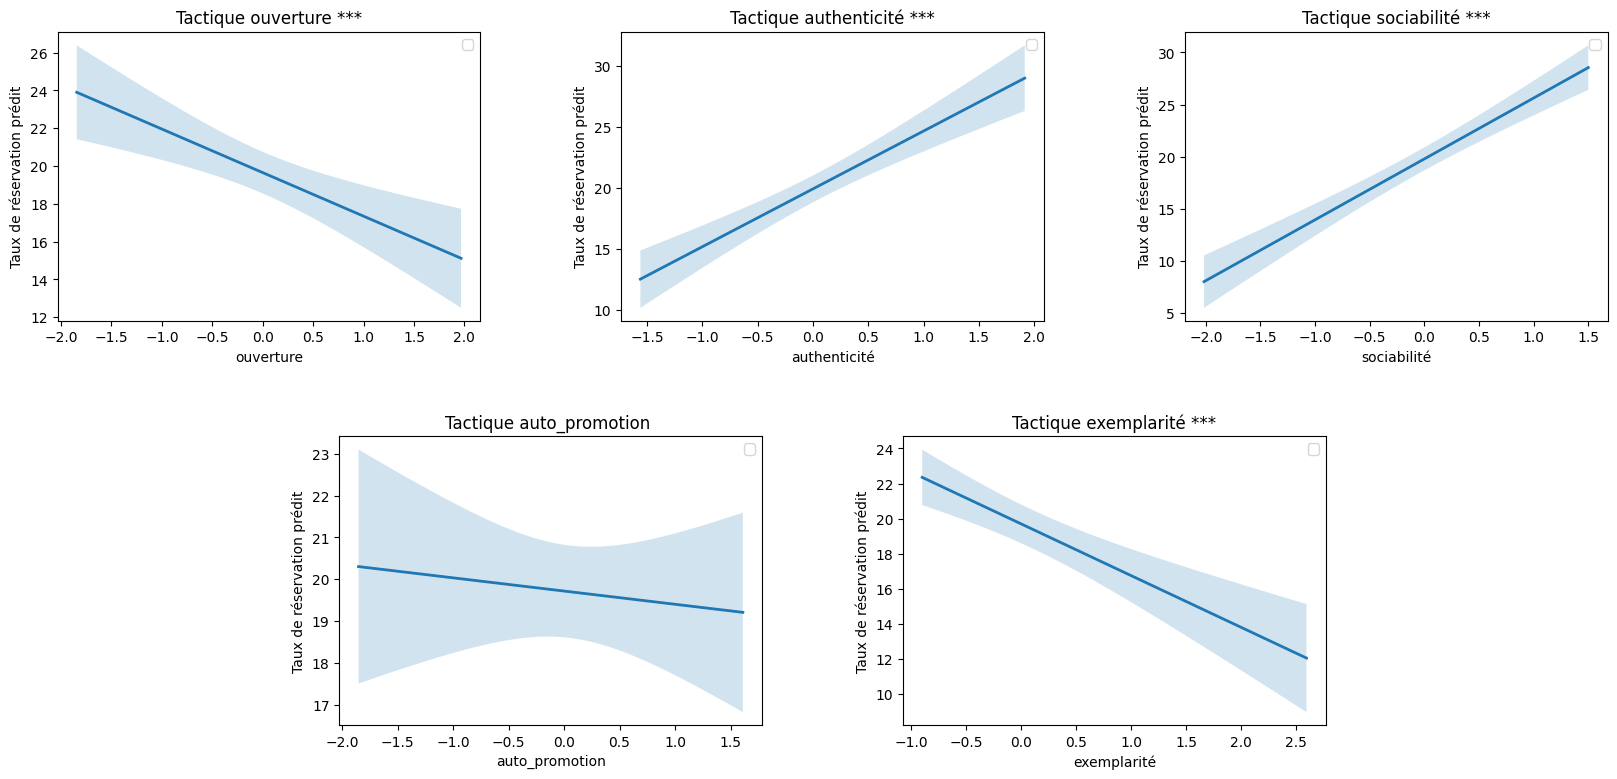

=========================================interaction plots==========================================
[INFO] formula :
 number_of_reviews ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ C(host_is_superhost) * (ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted)

C(host_is_superhost)[T.t]:openness
coef : [-4.05077729]; pval :0.000 

[INFO] formula :
 number_of_reviews ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + years_since_host + professional_host + len + price + availability_30+ C(host_is_superhost) * (ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted)

C(host_is_superhost)[T.t]:authenticity
coef : [4.90489324]; pval :0.000 

[INFO] f

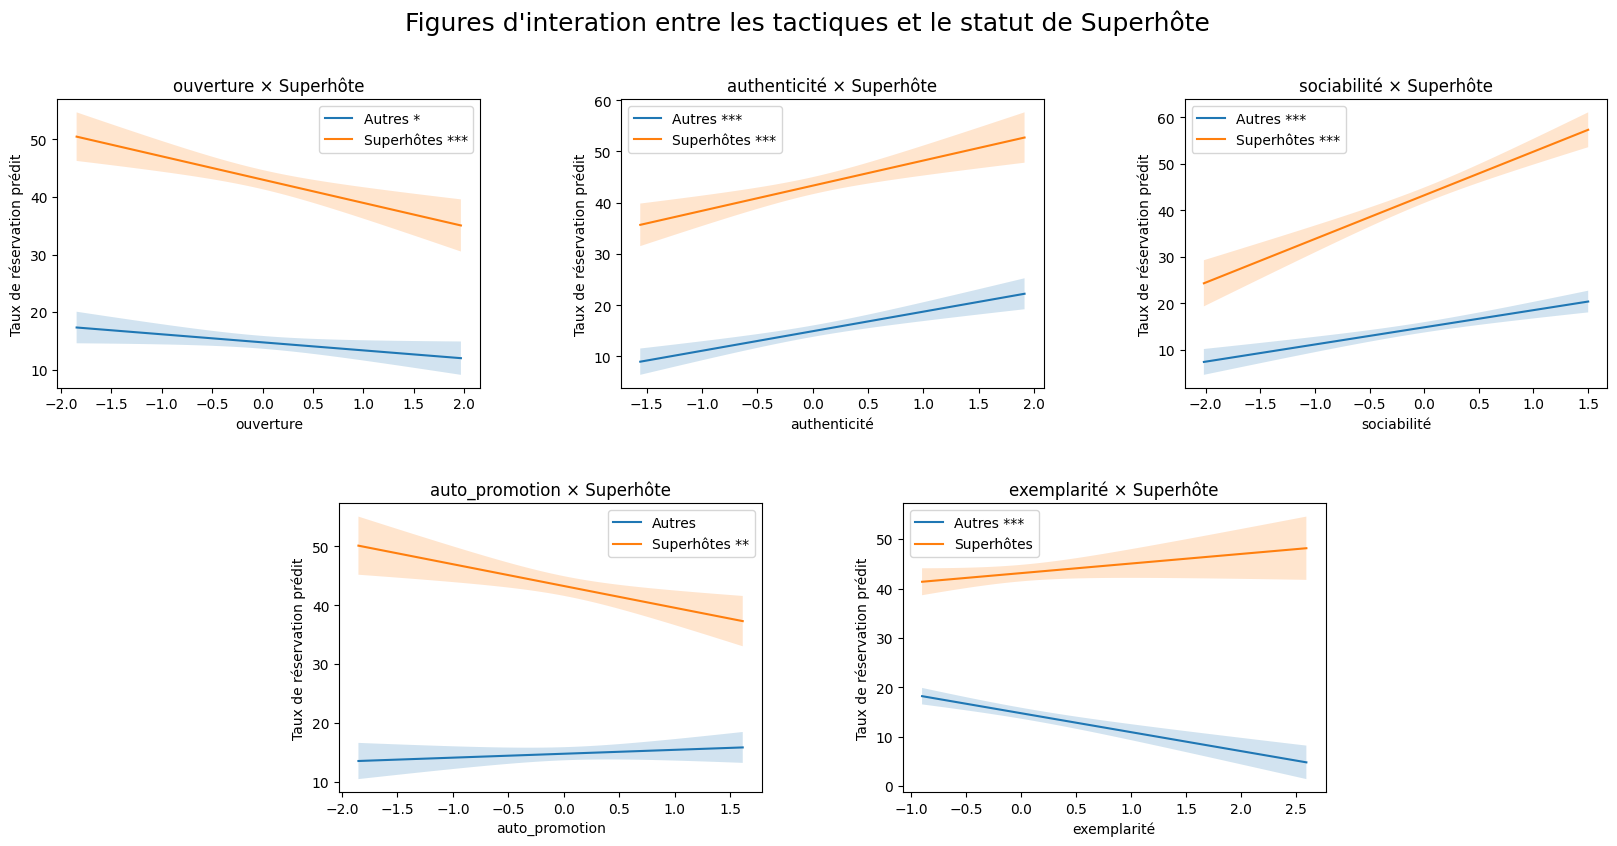

In [344]:
### pb de number_of_reviews
## as y 
y_var="number_of_reviews"

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', #'calculated_host_listings_count',
    "lang", "len",
    "price", "availability_30", "room_type", "instant_bookable"
]  
#加不加has_rating, count差别不大！
# calculated_host_listings_count
# "property_type"
 
tactics_vars_weighted=["ouverture_weighted", "authenticité_weighted","sociabilité_weighted","auto_promotion_weighted","exemplarité_weighted"]    
group_col="host_is_superhost"


output_folder='mod_results_Y_nb_reviews'

importlib.reload(modeling)
from utils.modeling import modeling_main
modeling_main(df_input=df_filtered, 
            x_vars=x_vars, 
            y_var=y_var, 
            key_vars=tactics_vars_weighted, 
            group_col=group_col,
            output_folder=output_folder,
            save_models_summary=False,  
            save_models_table=True,
            save_plots=True
            )

========================================check output folder=========================================
[INFO] results saved to mod_results+nb_reviews!

================================================vif=================================================
[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\miniconda3\envs\airbnb_env\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Variables,VIF,Niveau_colinearite
0,Intercept,594.022485,***
1,C(host_identity_verified)[T.t],1.012637,*
2,C(host_has_profile_pic)[T.t],1.006632,*
3,C(host_is_superhost)[T.t],1.173505,*
4,C(lang)[T.fr],1.304969,*
5,C(lang)[T.no_text],NaN,***
6,C(lang)[T.other_langs],1.026185,*
7,C(room_type)[T.Hotel room],1.106518,*
8,C(room_type)[T.Private room],1.088824,*
9,C(room_type)[T.Shared room],1.008736,*


============================================basic model=============================================
[CHECK] isna False in all 16 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  has_rating  number_of_reviews  years_since_host  professional_host  host_is_superhost  calculated_host_listings_count  lang   len    price  availability_30  room_type  instant_bookable  booking_rate_l30d
False                   False                 False                 False       False              False             False              False              False                           False  False  False  False            False      False             False                37013
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(host_is_superhost) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_c

,Basique,Tactiques,x Superhôte
C(host_is_superhost)[T.t],0.0050**\n(0.0025),0.0050*\n(0.0025),0.0058**\n(0.0025)
ouverture_weighted,,0.0000\n(0.0019),0.0022\n(0.0022)
C(host_is_superhost)[T.t]:ouverture_weighted,,,-0.0082**\n(0.0039)
authenticité_weighted,,-0.0006\n(0.0021),0.0021\n(0.0024)
C(host_is_superhost)[T.t]:authenticité_weighted,,,-0.0100**\n(0.0045)
sociabilité_weighted,,0.0020\n(0.0018),0.0033\n(0.0021)
C(host_is_superhost)[T.t]:sociabilité_weighted,,,-0.0052\n(0.0042)
auto_promotion_weighted,,-0.0004\n(0.0021),0.0035\n(0.0025)
C(host_is_superhost)[T.t]:auto_promotion_weighted,,,-0.0133***\n(0.0046)
exemplarité_weighted,,-0.0030*\n(0.0018),-0.0053**\n(0.0021)


...

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:526: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:526: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[SAVE] plots saved to mod_results+nb_reviews\tactics_plots.jpg!


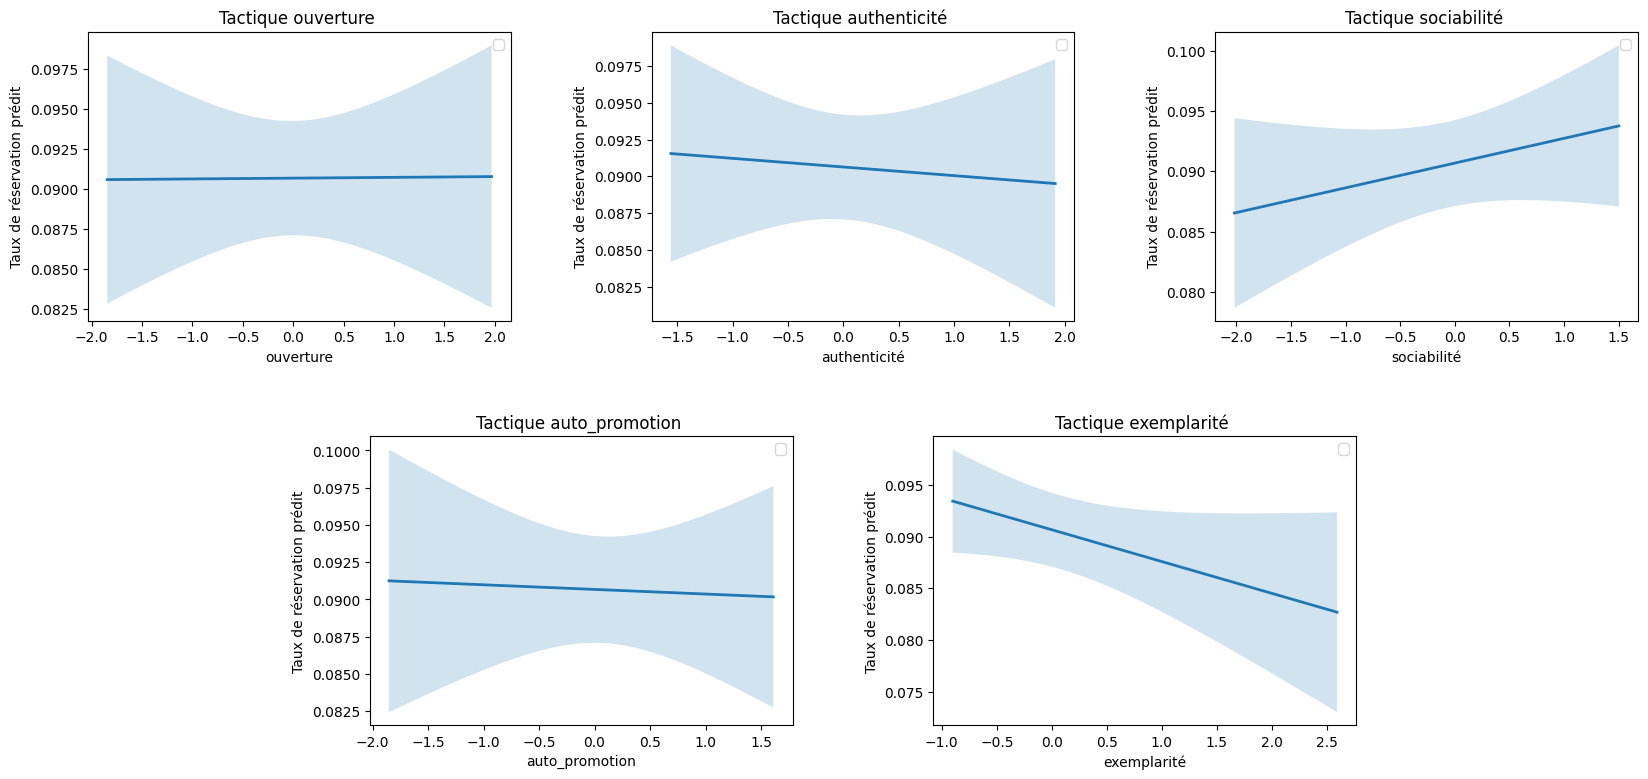

=========================================interaction plots==========================================
[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ C(host_is_superhost) * (ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted)

C(host_is_superhost)[T.t]:openness
coef : [-0.00602647]; pval :0.078 

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ C(host_is_superhost) * (ouverture_weighted + authenticité_weighted + sociabilité_weighted +

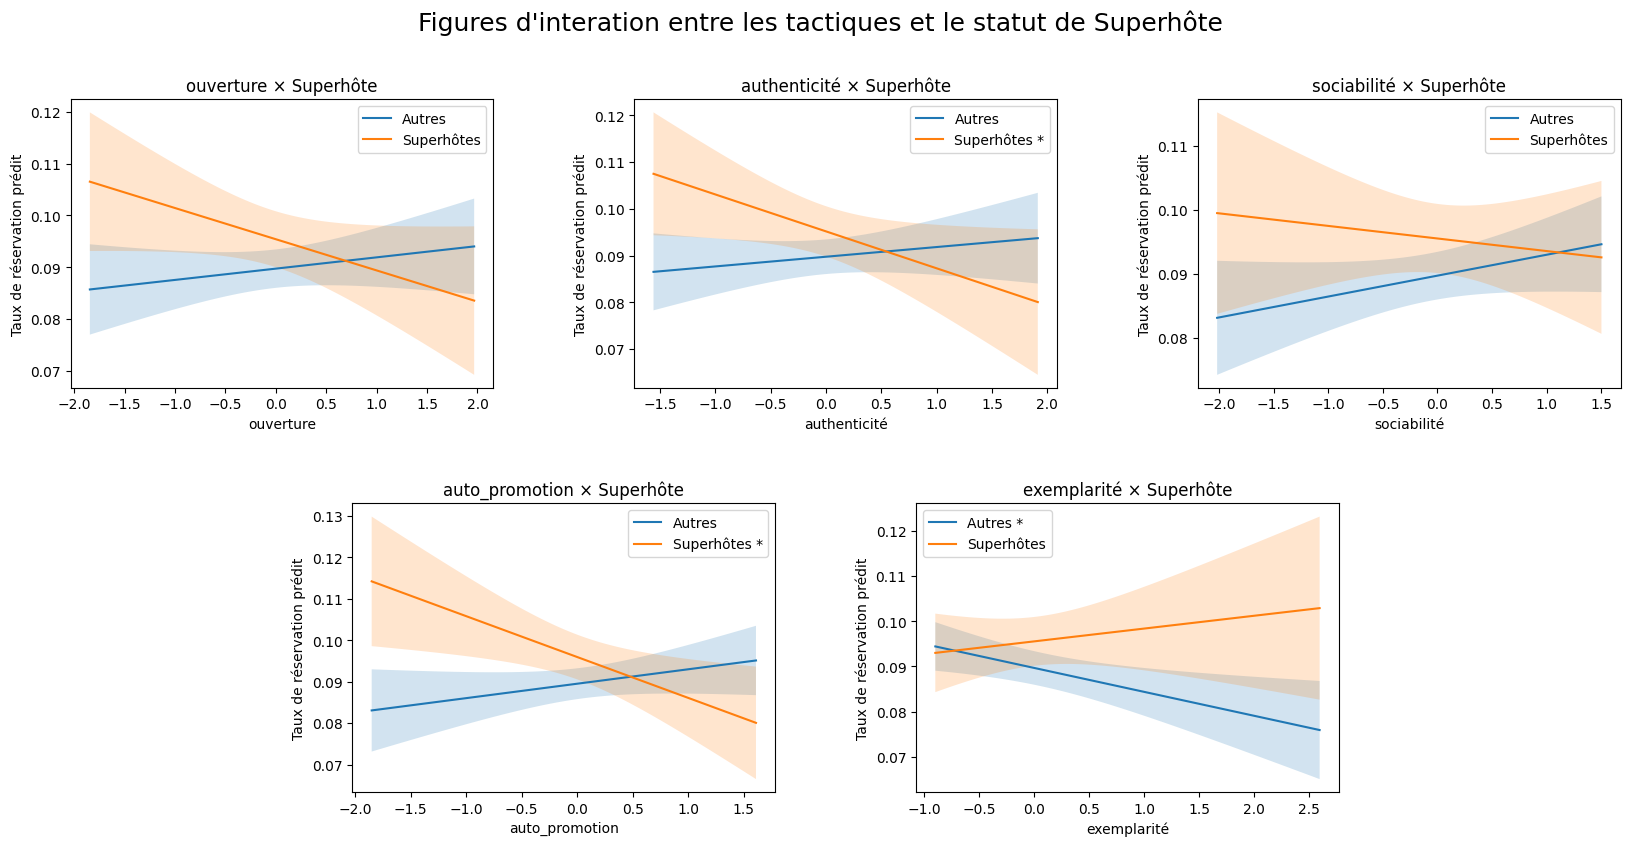

In [342]:
### pb de number_of_reviews
## as x 
y_var="booking_rate_l30d"

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", "has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', 'calculated_host_listings_count',
    "lang", "len",
    "price", "availability_30", "room_type", "instant_bookable"
]  
#加不加has_rating, count差别不大！
# calculated_host_listings_count
# "property_type"
 
tactics_vars_weighted=["ouverture_weighted", "authenticité_weighted","sociabilité_weighted","auto_promotion_weighted","exemplarité_weighted"]    
group_col="host_is_superhost"



output_folder='mod_results+nb_reviews'

importlib.reload(modeling)
from utils.modeling import modeling_main
modeling_main(df_input=df_filtered, 
            x_vars=x_vars, 
            y_var=y_var, 
            key_vars=tactics_vars_weighted, 
            group_col=group_col,
            output_folder=output_folder,
            save_models_summary=False,  
            save_models_table=True,
            save_plots=True
            )

## modeling step by step

In [333]:
check_vif (df=df_filtered, x_vars=x_vars, y_var=y_var, key_vars=tactics_vars_weighted, group_col=None)


[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\miniconda3\envs\airbnb_env\lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Variables,VIF,Niveau_colinearite
0,Intercept,586.588899,***
1,C(host_identity_verified)[T.t],1.012487,*
2,C(host_has_profile_pic)[T.t],1.006546,*
3,C(lang)[T.fr],1.304298,*
4,C(lang)[T.no_text],NaN,***
5,C(lang)[T.other_langs],1.026180,*
6,C(room_type)[T.Hotel room],1.106462,*
7,C(room_type)[T.Private room],1.087448,*
8,C(room_type)[T.Shared room],1.008656,*
9,C(instant_bookable)[T.t],1.314065,*


In [334]:
importlib.reload(modeling)
from utils.modeling import write_formula, check_vif, build_model

# basic model:
df, formula, model_basic=build_model (df_input=df_filtered,
            x_vars=x_vars, key_vars=None, 
            to_fillna0=True,
            y_var=y_var, group_col=None, 
            outpath_folder=output_folder, 
            tex_filename='ols_summary_basic.tex', 
            save=False)

[CHECK] isna False in all 15 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  has_rating  number_of_reviews  years_since_host  professional_host  calculated_host_listings_count  lang   len    price  availability_30  room_type  instant_bookable  booking_rate_l30d
False                   False                 False                 False       False              False             False              False                           False  False  False  False            False      False             False                37013
Name: count, dtype: int64

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l30d   R-squ

In [335]:
## model with tactics:
df, formula, model_tactics=build_model (df_input=df_filtered,
            x_vars=x_vars, key_vars=tactics_vars_weighted, 
            to_fillna0=True,
            y_var='booking_rate_l30d', group_col=None, 
            outpath_folder=output_folder, 
            tex_filename='ols_summary_tactics.tex', 
            save=False)

[CHECK] isna False in all 20 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  has_rating  number_of_reviews  years_since_host  professional_host  calculated_host_listings_count  lang   len    price  availability_30  room_type  instant_bookable  booking_rate_l30d  ouverture_weighted  authenticité_weighted  sociabilité_weighted  auto_promotion_weighted  exemplarité_weighted
False                   False                 False                 False       False              False             False              False                           False  False  False  False            False      False             False              True                True                   True                  True                     True                    20933
                                                                                                                                                                                                                                 

In [336]:
## model with interaction :
df, formula, model_interaction=build_model (df_input=df_filtered, 
            x_vars=x_vars, key_vars=tactics_vars_weighted, 
            to_fillna0=True,
            y_var='booking_rate_l30d', group_col="host_is_superhost", 
            outpath_folder=output_folder, 
            tex_filename='ols_summary_interaction.tex', 
            save=False)


[CHECK] isna False in all 20 vars : host_identity_verified  host_has_profile_pic  review_scores_rating  has_rating  number_of_reviews  years_since_host  professional_host  calculated_host_listings_count  lang   len    price  availability_30  room_type  instant_bookable  booking_rate_l30d  ouverture_weighted  authenticité_weighted  sociabilité_weighted  auto_promotion_weighted  exemplarité_weighted
False                   False                 False                 False       False              False             False              False                           False  False  False  False            False      False             False              True                True                   True                  True                     True                    20933
                                                                                                                                                                                                                                 

## summary to latex:

In [337]:
importlib.reload(modeling)
from utils.modeling import make_models_table

models_dict = {
    "Basique": model_basic,
    "Tactiques  ": model_tactics,
    "x Superhôte": model_interaction
}

table_kp, table_ctrl=make_models_table(models_dict=models_dict, 
                vars_kp=tactics_vars_weighted+[group_col], 
                save=True, output_folder=output_folder, filename_noext=None)

,Basique,Tactiques,x Superhôte
C(host_is_superhost)[T.t],,,0.0058**\n(0.0025)
ouverture_weighted,,0.0000\n(0.0019),0.0022\n(0.0022)
C(host_is_superhost)[T.t]:ouverture_weighted,,,-0.0082**\n(0.0039)
authenticité_weighted,,-0.0006\n(0.0021),0.0021\n(0.0024)
C(host_is_superhost)[T.t]:authenticité_weighted,,,-0.0100**\n(0.0045)
sociabilité_weighted,,0.0021\n(0.0018),0.0033\n(0.0021)
C(host_is_superhost)[T.t]:sociabilité_weighted,,,-0.0052\n(0.0042)
auto_promotion_weighted,,-0.0003\n(0.0021),0.0035\n(0.0025)
C(host_is_superhost)[T.t]:auto_promotion_weighted,,,-0.0133***\n(0.0046)
exemplarité_weighted,,-0.0031*\n(0.0018),-0.0053**\n(0.0021)


,Basique,Tactiques,x Superhôte
C(host_identity_verified)[T.t],0.0019\n(0.0046),0.0021\n(0.0046),0.0017\n(0.0046)
C(host_has_profile_pic)[T.t],-0.0085\n(0.0057),-0.0084\n(0.0057),-0.0087\n(0.0057)
C(lang)[T.fr],0.0072**\n(0.0029),0.0081**\n(0.0033),0.0082**\n(0.0033)
C(lang)[T.no_text],0.0156***\n(0.0029),0.0167***\n(0.0030),0.0166***\n(0.0030)
C(lang)[T.other_langs],0.0188*\n(0.0097),0.0196**\n(0.0097),0.0197**\n(0.0097)
C(room_type)[T.Hotel room],-0.0663***\n(0.0083),-0.0671***\n(0.0083),-0.0681***\n(0.0083)
C(room_type)[T.Private room],0.0139***\n(0.0032),0.0135***\n(0.0032),0.0135***\n(0.0032)
C(room_type)[T.Shared room],0.0027\n(0.0114),0.0024\n(0.0114),0.0027\n(0.0114)
C(instant_bookable)[T.t],0.0145***\n(0.0023),0.0144***\n(0.0024),0.0141***\n(0.0024)
review_scores_rating,0.0179***\n(0.0026),0.0177***\n(0.0026),0.0166***\n(0.0026)


[SAVE] table latex saved to mod_results+nb_reviews\table_mods_keyvars.tex!

[SAVE] table latex saved to mod_results+nb_reviews\table_mods_ctrlvars.tex!



## 5plots：

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:526: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:526: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



...

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:526: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted



d:\Edu\selfpresentation-NLI-airbnb\utils\modeling.py:526: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


[SAVE] plots saved to mod_results+nb_reviews\tactics_plots.jpg!


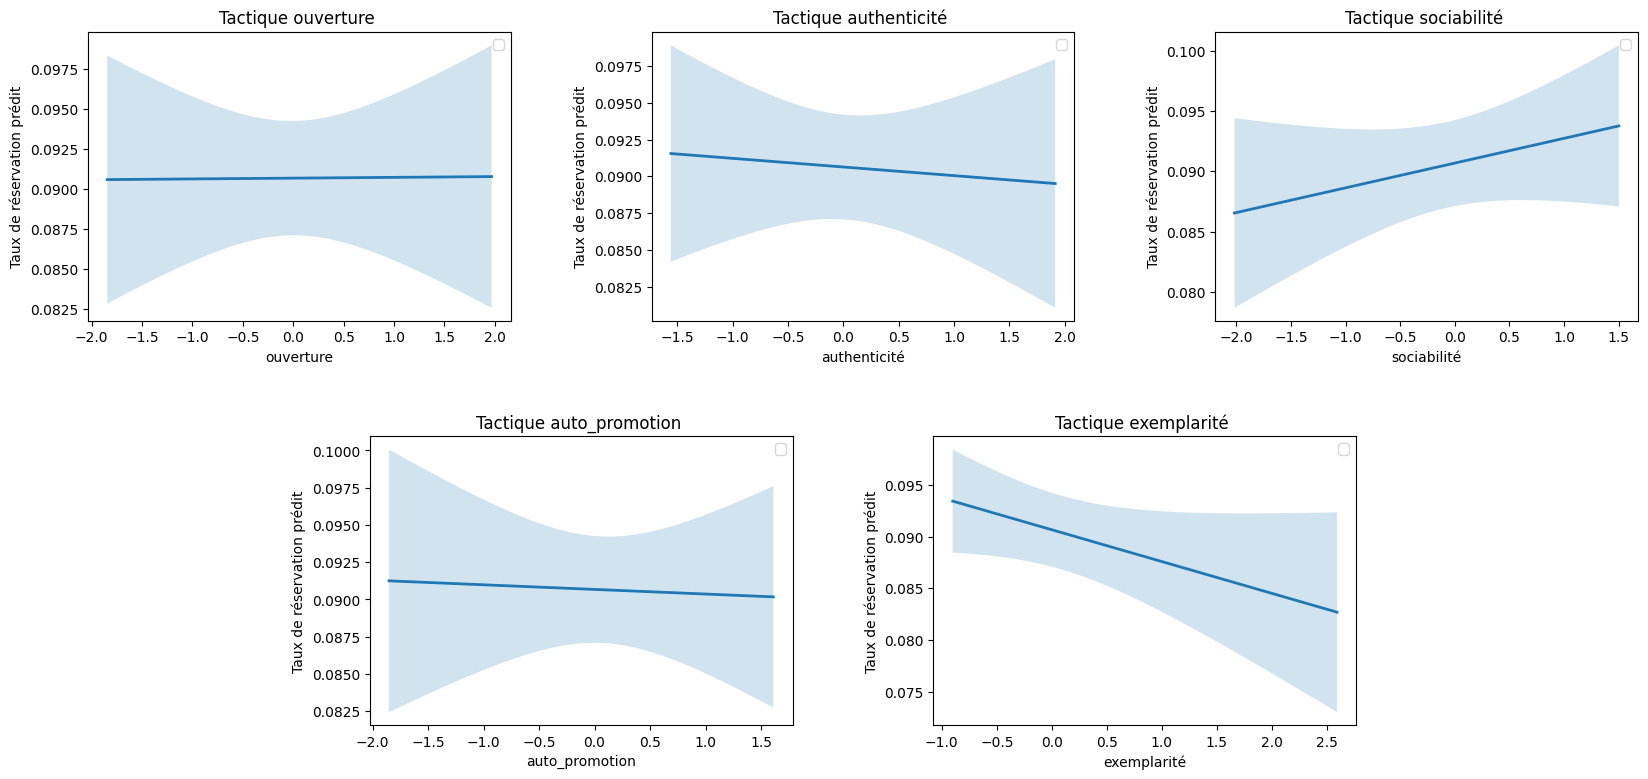

(<Figure size 2000x900 with 5 Axes>,
 [<Axes: title={'center': 'Tactique ouverture '}, xlabel='ouverture', ylabel='Taux de réservation prédit'>,
  <Axes: title={'center': 'Tactique authenticité '}, xlabel='authenticité', ylabel='Taux de réservation prédit'>,
  <Axes: title={'center': 'Tactique sociabilité '}, xlabel='sociabilité', ylabel='Taux de réservation prédit'>,
  <Axes: title={'center': 'Tactique auto_promotion '}, xlabel='auto_promotion', ylabel='Taux de réservation prédit'>,
  <Axes: title={'center': 'Tactique exemplarité '}, xlabel='exemplarité', ylabel='Taux de réservation prédit'>])

In [338]:
importlib.reload(modeling)
from utils.modeling import layout_plots
layout_plots(df_input=df_filtered, x_vars=x_vars,y_var=y_var,
            tactics_vars=tactics_vars_weighted, 
            group_col=None,
            save=True, 
            output_folder=output_folder,
            filename=None)

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ C(host_is_superhost) * (ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted)

C(host_is_superhost)[T.t]:openness
coef : [-0.00602647]; pval :0.078 

[INFO] formula :
 booking_rate_l30d ~ C(host_identity_verified) + C(host_has_profile_pic) + C(lang) + C(room_type) + C(instant_bookable) + review_scores_rating + has_rating + number_of_reviews + years_since_host + professional_host + calculated_host_listings_count + len + price + availability_30+ C(host_is_superhost) * (ouverture_weighted + authenticité_weighted + sociabilité_weighted + auto_promotion_weighted + exemplarité_weighted)

C(host_is_superhost)[T.t]:authenticity
coef : [-0.0

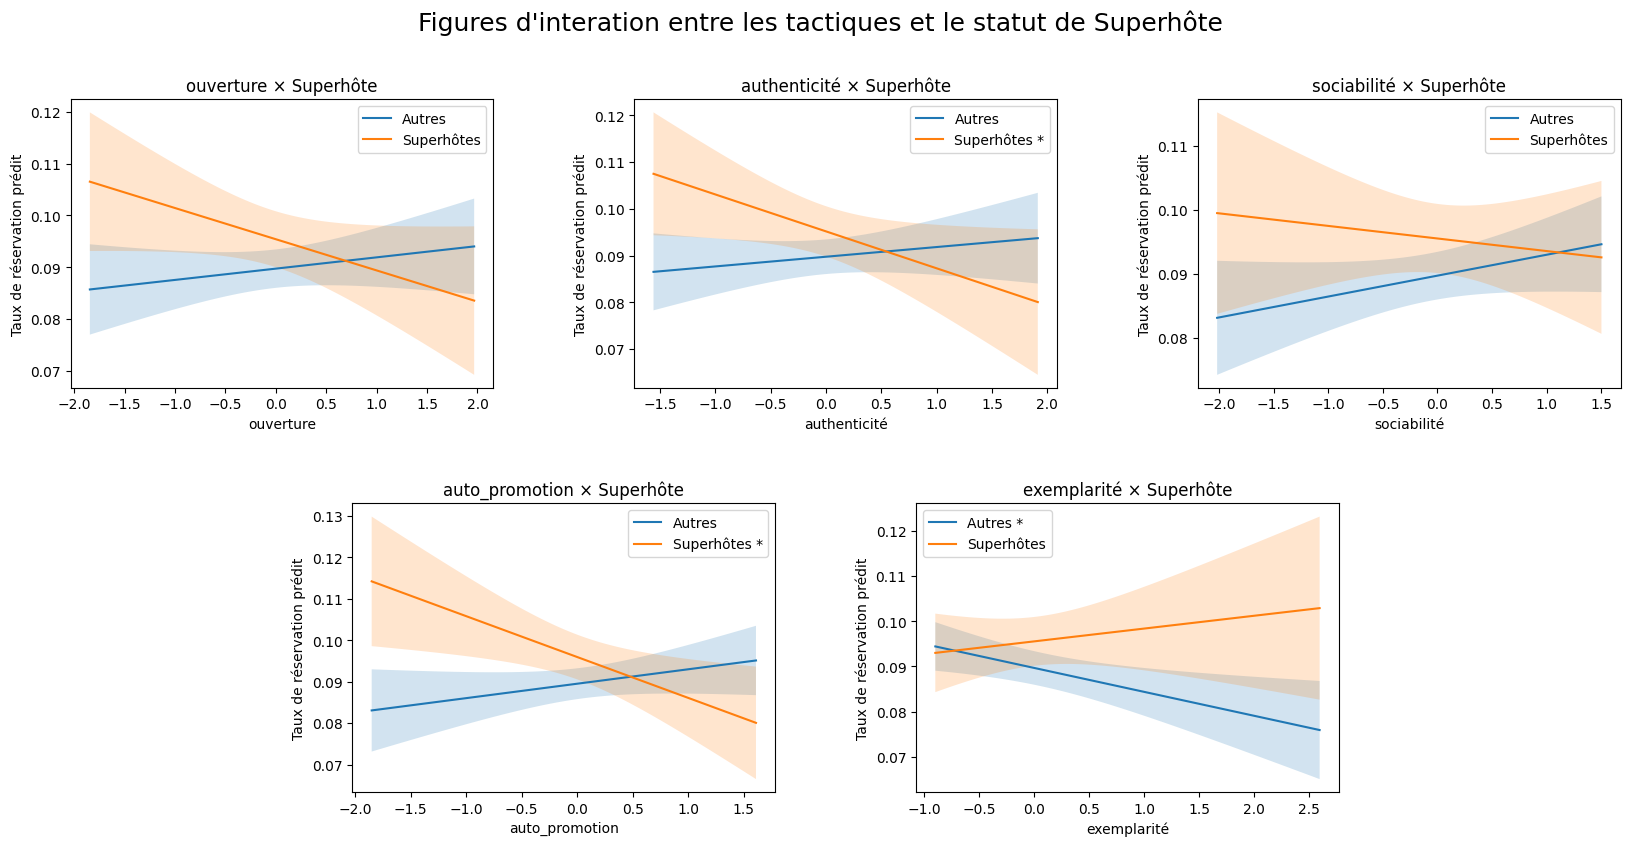

(<Figure size 2000x900 with 5 Axes>,
 [<Axes: title={'center': 'ouverture × Superhôte'}, xlabel='ouverture', ylabel='Taux de réservation prédit'>,
  <Axes: title={'center': 'authenticité × Superhôte'}, xlabel='authenticité', ylabel='Taux de réservation prédit'>,
  <Axes: title={'center': 'sociabilité × Superhôte'}, xlabel='sociabilité', ylabel='Taux de réservation prédit'>,
  <Axes: title={'center': 'auto_promotion × Superhôte'}, xlabel='auto_promotion', ylabel='Taux de réservation prédit'>,
  <Axes: title={'center': 'exemplarité × Superhôte'}, xlabel='exemplarité', ylabel='Taux de réservation prédit'>])

In [339]:
importlib.reload(modeling)
from utils.modeling import layout_plots
layout_plots(df_input=df_filtered, x_vars=x_vars,y_var=y_var,
            tactics_vars=tactics_vars_weighted,
            save=True, 
            group_col='host_is_superhost', 
            output_folder=output_folder,
            )